# Comparing models trained with LFP loss vs not

Looking at the saved neural data from these models

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d
import pickle as pk
import sys
import importlib

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld
import population_utils as pu

2025-09-14 23:58:05.028792: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-14 23:58:05.037929: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-14 23:58:05.047754: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-14 23:58:05.050732: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-14 23:58:05.058547: I tensorflow/core/platform/cpu_feature_guar

## get list of trained models

In [2]:
# non-lfp models (xlfp)

xlfp_model_dir = '/home/nuttidalab/Documents/renee/nonlfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
xlfp_model_list = ld.find_files_keywords(xlfp_model_dir, ['09_03', '.mat'])
xlfp_model_list = [m.split('/')[-1] for m in xlfp_model_list]
xlfp_model_list.sort()
# print(xlfp_model_list)
print(len(xlfp_model_list))

perfs = []
train_trials = []
for i, model_name in enumerate(xlfp_model_list):
    model_path = os.path.join(xlfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

11
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_09_03_124351.mat, Test perf: 0.97, Train trials: 11501
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_09_03_124357.mat, Test perf: 0.98, Train trials: 11201
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_09_03_124459.mat, Test perf: 1.0, Train trials: 11701
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_09_03_125248.mat, Test perf: 0.99, Train trials: 8501
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_09_03_125609.mat, Test perf: 0.97, Train trials: 13601
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_09_03_130506.mat, Test perf: 0.97, Train trials: 9801
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_09_03_130812.mat, Test perf: 1.0, Train trials: 17001
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_09_03_132217.mat, Test perf: 0.98, Train trials: 19401
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_09_03_132359.mat, Test perf: 0.98, Train trials: 18001
Model: Task_xor_N_200_Taus_4.

In [ ]:
# lfp models (lfp) — theta

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
# lfp_model_list = os.listdir(lfp_model_dir)
# lfp_model_list = [m for m in lfp_model_list if m.endswith('.mat') and m.]
lfp_theta_model_list = ld.find_files_keywords(lfp_model_dir, ['Jitter_10_10', '4.0_8.0', '.mat'])
# remove directories 
lfp_theta_model_list = [m.split('/')[-1] for m in lfp_theta_model_list]
lfp_theta_model_list.sort()

# remove the last model, which was trained with different parameters
lfp_theta_model_list = lfp_theta_model_list[:-1]
# print(lfp_theta_model_list)
print(len(lfp_theta_model_list))

perfs = []
train_trials = []
for i, model_name in enumerate(lfp_theta_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

43
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_234639.mat, Test perf: 0.99, Train trials: 14501
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_234746.mat, Test perf: 0.99, Train trials: 15101
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_235932.mat, Test perf: 0.98, Train trials: 22901
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_001147.mat, Test perf: 0.99, Train trials: 14401
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_001501.mat, Test perf: 0.98, Train trials: 16001
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_002309.mat, Test perf: 1.0, Train trials: 13401
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_005236.mat, Test perf: 0.97, Train trials: 17401
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_010607.mat, Test perf: 1.0, Train trials: 7801
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_014146.mat, Test perf: 1.0, Train trials: 12101
Model: Task_xor_N_200_Jitter_10_10_LFP

In [8]:
# lfp models (lfp) — theta

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
# lfp_model_list = os.listdir(lfp_model_dir)
# lfp_model_list = [m for m in lfp_model_list if m.endswith('.mat') and m.]
lfp_theta_model_list = ld.find_files_keywords(lfp_model_dir, ['LFPdelay','Jitter_10_10', '4.0_8.0', '2025_09_1', '.mat'])
# remove directories 
lfp_theta_model_list = [m.split('/')[-1] for m in lfp_theta_model_list]
lfp_theta_model_list.sort()

# print(lfp_theta_model_list)
print(len(lfp_theta_model_list))

perfs = []
train_trials = []
for i, model_name in enumerate(lfp_theta_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

2
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_8.0_2025_09_14_172300.mat, Test perf: 1.0, Train trials: 39999
Model: Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_8.0_2025_09_15_002104.mat, Test perf: 1.0, Train trials: 39701


In [ ]:
# lfp models (lfp) — alpha -- havent' run data, so don't run this cell

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
# lfp_model_list = os.listdir(lfp_model_dir)
# lfp_model_list = [m for m in lfp_model_list if m.endswith('.mat') and m.]
lfp_alpha_model_list = ld.find_files_keywords(lfp_model_dir, ['08_21', '9.0_12.0', '.mat'])
# remove directories 
lfp_alpha_model_list = [m.split('/')[-1] for m in lfp_alpha_model_list]
lfp_alpha_model_list.sort()

# remove the last model, which was trained with different parameters
lfp_alpha_model_list = lfp_alpha_model_list[:-1]
# print(lfp_alpha_model_list)
print(len(lfp_alpha_model_list))

perfs = []
train_trials = []
for i, model_name in enumerate(lfp_alpha_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

['Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_151257.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_153737.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_164712.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_164821.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_172517.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_172805.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_174006.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_174857.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_181822.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_182141.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_183023.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_185725.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigm

## study models

### dict keys
neural_dict has 2 keys:
- 'r' is trials x neurons x time
- 'epsp' is trials x time

bhv_dict has 2 keys:
- 'perf' is trials (0/1)
- 'trial_type' is list of length trials
    - if changed to np.array, is trials x 2

In [ ]:
# delay150
settings = {
        'T': 400, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4, 8], # theta
        'fs': 200,
        'task': 'xor', # task name
        }

In [ ]:
# base code for loading data for each model type

model_lists = [xlfp_model_list, lfp_theta_model_list] #, lfp_alpha_model_list]
model_dirs = [xlfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['xlfp', 'lfp_theta'] #, 'lfp_alpha']

for model_lists, model_dirs, model_list_names in zip(model_lists, model_dirs, model_list_names):
    model_list = model_lists
    model_dir = model_dirs
    model_list_name = model_list_names

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')

    for model_name in model_list:
        print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict.pkl'), 'rb'))
        bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict.pkl'), 'rb'))

        break
    break


### simple behavior plots

In [ ]:
avg_perf_lfp = []
avg_perf_xlfp = []

model_lists = [xlfp_model_list, lfp_theta_model_list] #, lfp_alpha_model_list]
model_dirs = [xlfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['xlfp', 'lfp_theta'] #, 'lfp_alpha']

for model_lists, model_dirs, model_list_names in zip(model_lists, model_dirs, model_list_names):
    model_list = model_lists
    model_dir = model_dirs
    model_list_name = model_list_names

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict.pkl'), 'rb'))
        if model_list_name == 'xlfp':
            avg_perf_xlfp.append(np.mean(bhv_dict['perf']))
        elif model_list_name == 'lfp_theta':
            avg_perf_lfp.append(np.mean(bhv_dict['perf']))
            
print(f'XLFP avg perf: {np.mean(avg_perf_xlfp)}, std: {np.std(avg_perf_xlfp)}')
print(f'LFP avg perf: {np.mean(avg_perf_lfp)}, std: {np.std(avg_perf_lfp)}')

Mann-Whitney U test statistic: 79.00, p-value: 0.24


/tmp/ipykernel_136371/4284956897.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([avg_perf_lfp, avg_perf_xlfp], labels=['LFP', 'X-LFP'])


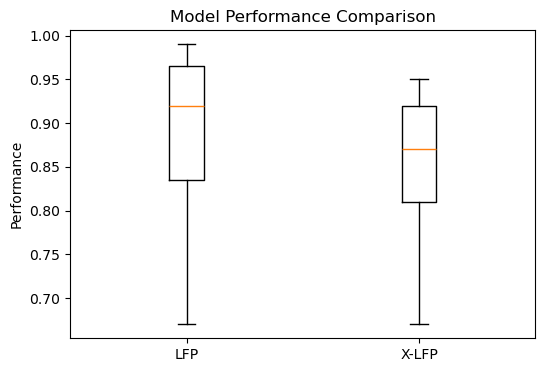

In [ ]:
# box plots comparing model perfs from both groups, with stats -- from when there were 11 of each model type

plt.figure(figsize=(6,4))
plt.boxplot([avg_perf_lfp, avg_perf_xlfp], labels=['LFP', 'X-LFP'])

from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(avg_perf_lfp, avg_perf_xlfp)
print("Mann-Whitney U test statistic: %.2f, p-value: %.2f" % (stat, p))

if p<0.05:
    plt.text(1.2, 0.1, '*', fontsize=20, ha='center')

plt.ylabel('Performance')
plt.title('Model Performance Comparison')
# plt.grid()
plt.show()

### Plot rate trajectories

Processing model type: xlfp, number of models: 11
PCA explained variance: [0.6789845  0.09578656 0.07723114], total: 0.8520022045083562
PCA explained variance: [0.68177428 0.11245148 0.06820796], total: 0.8624337111130085
PCA explained variance: [0.56591242 0.1689792  0.11145199], total: 0.8463436144151029
PCA explained variance: [0.52518172 0.14571852 0.10742775], total: 0.7783279940221858
PCA explained variance: [0.70246939 0.10002128 0.05546545], total: 0.857956124922967
PCA explained variance: [0.37291346 0.25478539 0.14041353], total: 0.7681123755453869
PCA explained variance: [0.65728122 0.12769568 0.08729934], total: 0.8722762416272287
PCA explained variance: [0.70720846 0.09922514 0.06425325], total: 0.8706868406020113
PCA explained variance: [0.60830057 0.12615047 0.08570775], total: 0.8201587892346872
PCA explained variance: [0.64559377 0.11714911 0.06833391], total: 0.831076784666132
PCA explained variance: [0.54136349 0.20496648 0.07430035], total: 0.8206303236002804
Proces

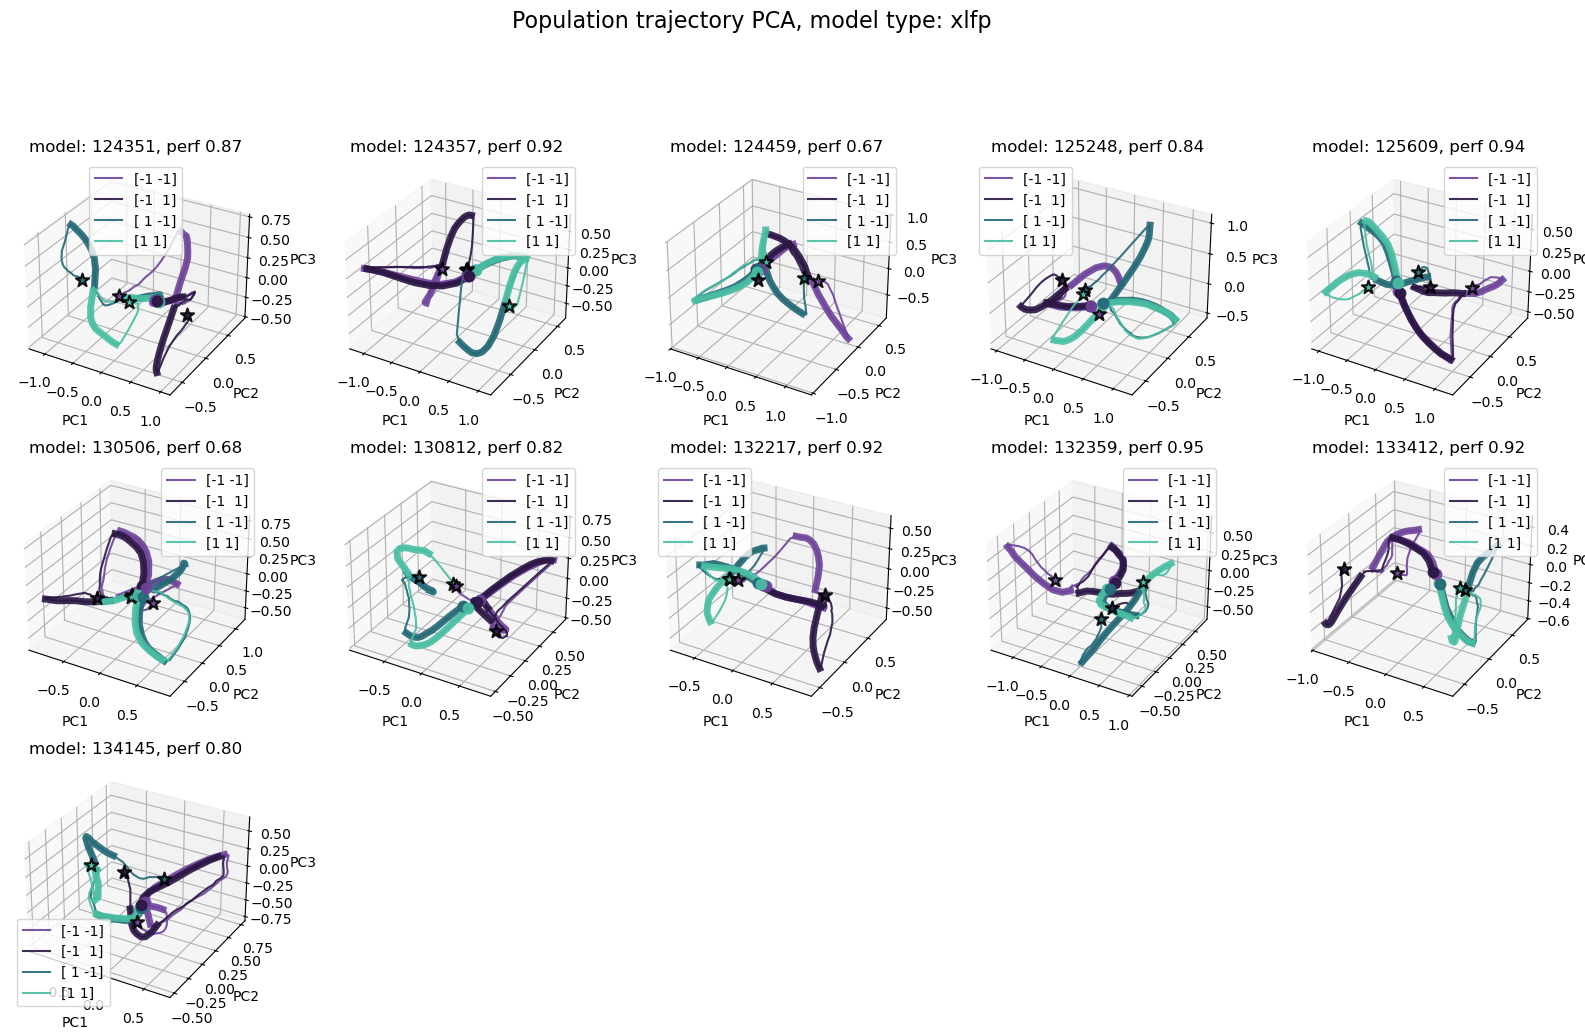

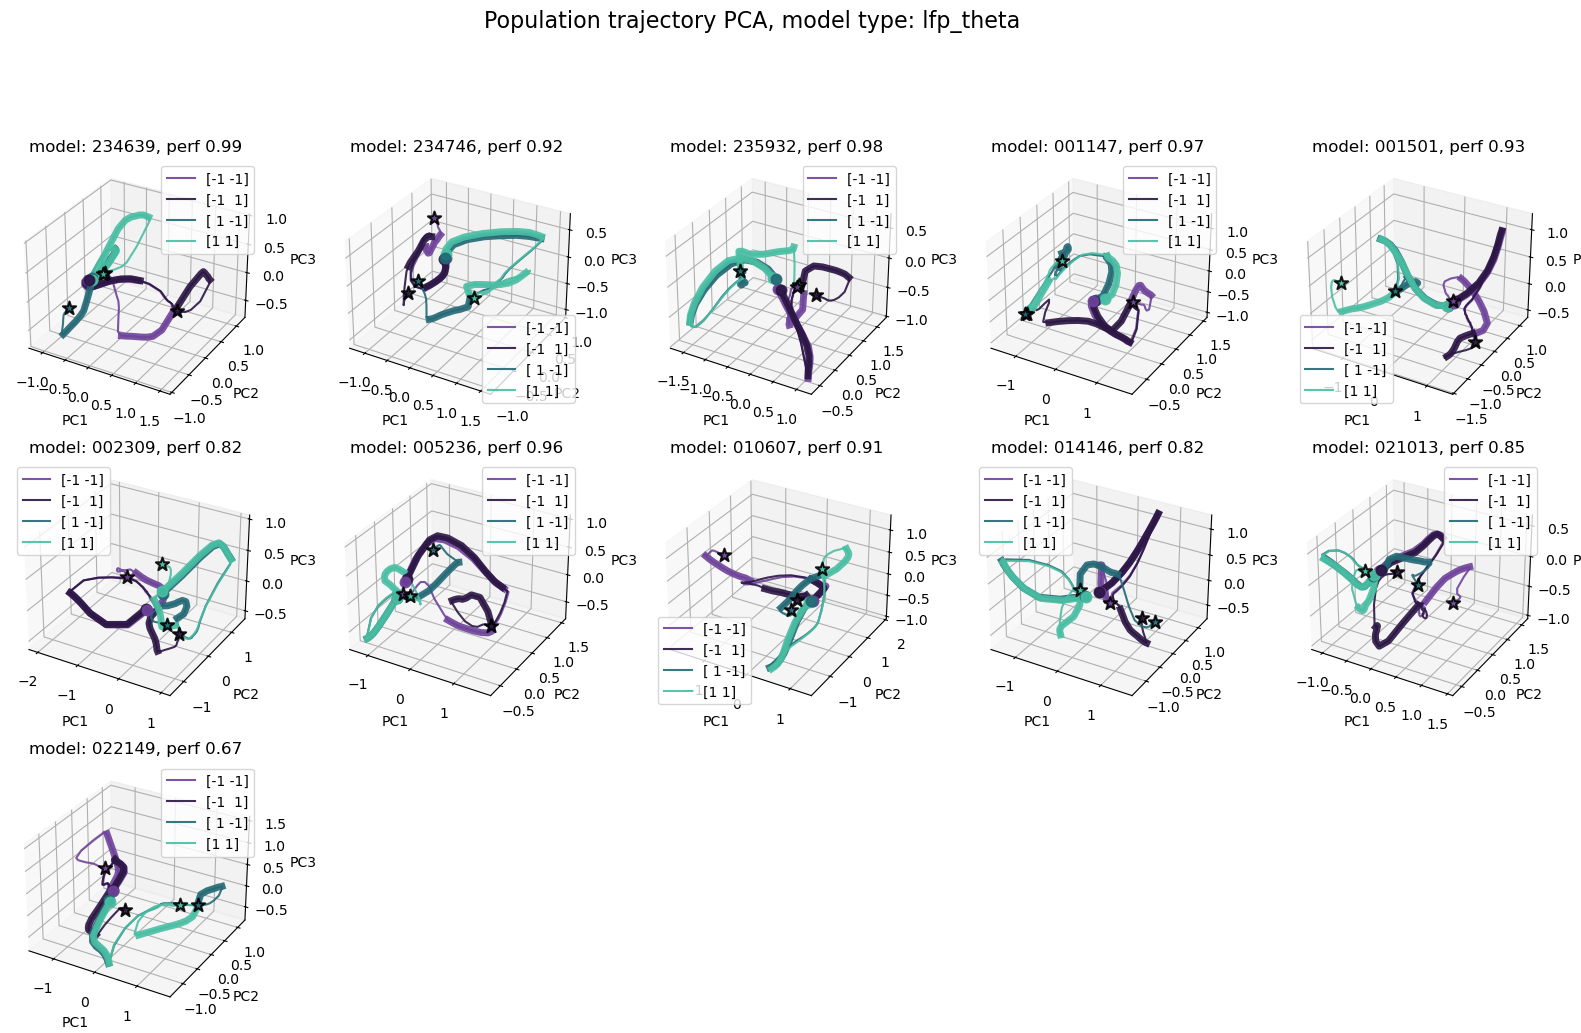

In [9]:
model_lists = [xlfp_model_list, lfp_theta_model_list] #, lfp_alpha_model_list]
model_dirs = [xlfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['xlfp', 'lfp_theta'] #, 'lfp_alpha']

for model_lists, model_dirs, model_list_names in zip(model_lists, model_dirs, model_list_names):
    model_list = model_lists
    model_dir = model_dirs
    model_list_name = model_list_names

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')
    
    # create figure
    fig = plt.figure(figsize=(20, 15))

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict.pkl'), 'rb'))
        bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict.pkl'), 'rb'))
        
        ax = fig.add_subplot(4, 5, model_list.index(model_name)+1, projection='3d')
        ax, _ = pu.plot_trajectory_pca(rates_data=neural_dict['r'], trial_labels=np.array(bhv_dict['trial_type']), 
                       settings=settings, cut_off=50, plot=1, ds=5, smooth=2, ax=ax,
                       title=f'model: {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    
    fig.suptitle(f'Population trajectory PCA, model type: {model_list_name}', fontsize=16)


Processing model type: xlfp, number of models: 11
PCA explained variance: [0.68390513 0.09584469 0.07054011], total: 0.850289934685851
PCA explained variance: [0.67980237 0.11114174 0.06838518], total: 0.8593293006838316
PCA explained variance: [0.4795197  0.21335978 0.10164591], total: 0.794525388848464
PCA explained variance: [0.52561102 0.15760157 0.09716272], total: 0.7803753057298581
PCA explained variance: [0.69868435 0.10114476 0.05579493], total: 0.8556240390550283
PCA explained variance: [0.37993537 0.23392931 0.1276728 ], total: 0.7415374807042157
PCA explained variance: [0.67738705 0.11259667 0.07909837], total: 0.8690820908319248
PCA explained variance: [0.71225235 0.09317778 0.06542431], total: 0.870854445444313
PCA explained variance: [0.60824472 0.12436705 0.08671093], total: 0.8193226942873781
PCA explained variance: [0.65394104 0.11193128 0.06451522], total: 0.8303875421325675
PCA explained variance: [0.53425108 0.20517139 0.07176675], total: 0.8111892210197209
Process

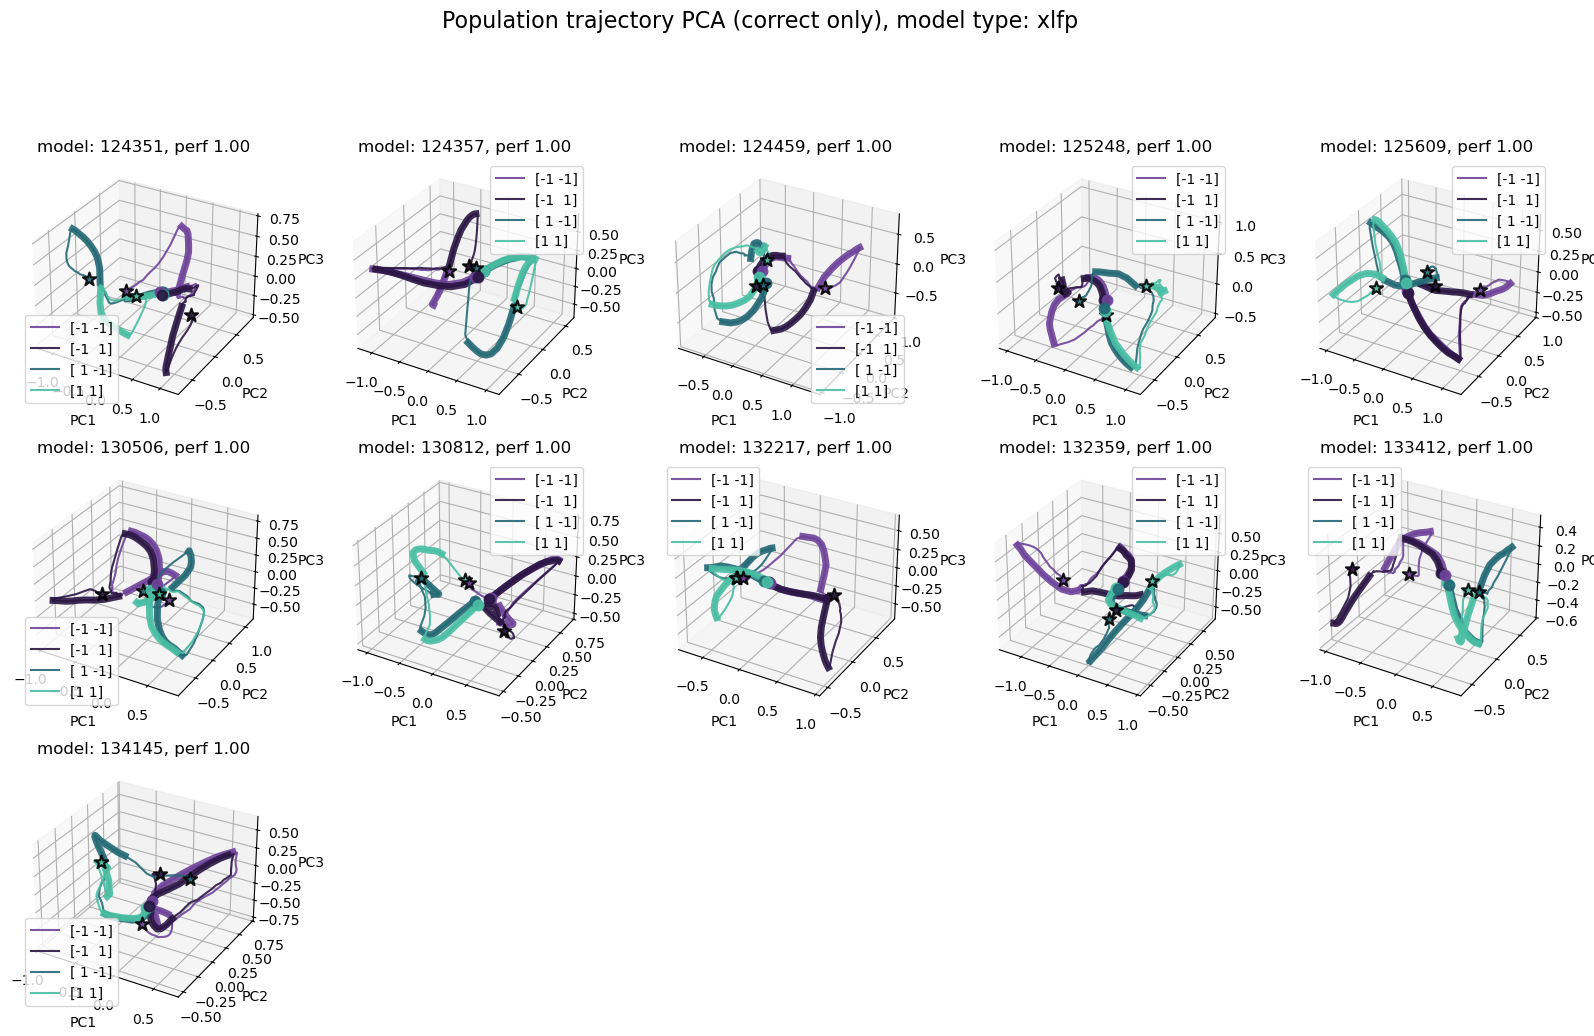

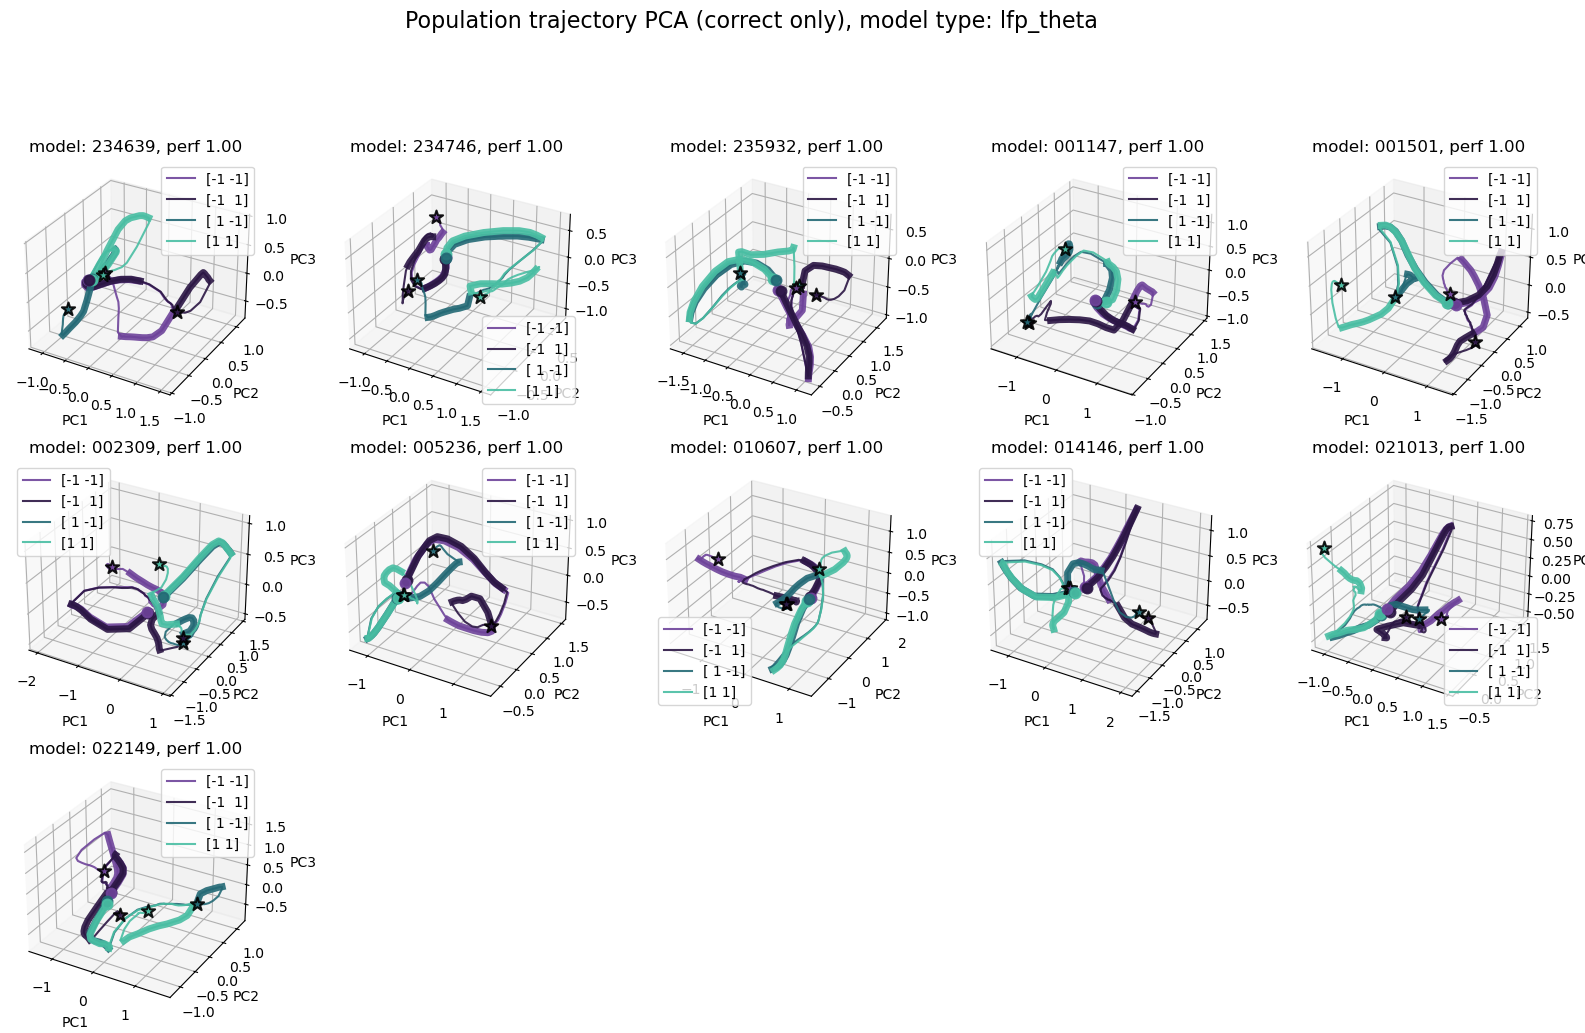

In [10]:
# trajectories for correct trials only

model_lists = [xlfp_model_list, lfp_theta_model_list] #, lfp_alpha_model_list]
model_dirs = [xlfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['xlfp', 'lfp_theta'] #, 'lfp_alpha']

for model_lists, model_dirs, model_list_names in zip(model_lists, model_dirs, model_list_names):
    model_list = model_lists
    model_dir = model_dirs
    model_list_name = model_list_names

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')
    
    # create figure
    fig = plt.figure(figsize=(20, 15))

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict.pkl'), 'rb'))
        bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict.pkl'), 'rb'))
        correct_trials = np.where(bhv_dict['perf'] == 1)[0]
        neural_dict['r'] = neural_dict['r'][correct_trials, :, :]
        bhv_dict['trial_type'] = np.array(bhv_dict['trial_type'])[correct_trials]
        bhv_dict['perf'] = np.array(bhv_dict['perf'])[correct_trials]
        
        ax = fig.add_subplot(4, 5, model_list.index(model_name)+1, projection='3d')
        ax, _ = pu.plot_trajectory_pca(rates_data=neural_dict['r'], trial_labels=np.array(bhv_dict['trial_type']), 
                       settings=settings, cut_off=50, plot=1, ds=5, smooth=2, ax=ax,
                       title=f'model: {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    
    fig.suptitle(f'Population trajectory PCA (correct only), model type: {model_list_name}', fontsize=16)

### plot EPSP

In [11]:
neural_dict['epsp'].shape

(100, 400)

In [12]:
# spect calculation function in numpy

def compute_lfp_power_np(epsp, settings):
    """
    Compute band-limited z-scored LFP power using Morlet wavelets (NumPy version).

    Parameters
    ----------
    epsp : list or np.ndarray
        Length-T list or array of scalar values (e.g., EPSP signal).
    settings : dict
        Dictionary containing:
            - 'T': int, length of the signal
            - 'fs': float, sampling frequency in Hz
            - 'lfp_power_target': list or tuple of [low_freq, high_freq]
            - 'stim_on': int, time index of stimulus onset

    Returns
    -------
    lfp_power_z : np.ndarray
        Z-scored LFP power in the target frequency band. Shape [T]
    """
    # --- settings ---
    T = settings['T']
    fs = settings['fs']
    dt = 1.0 / fs
    fmin, fmax = 4.0, 100.0
    num_freqs = 40
    band_lo, band_hi = settings['lfp_power_target']
    stim_on = settings['stim_on']

    # --- epsp input processing ---
    epsp_vec = np.squeeze(np.stack(epsp, axis=0))  # [T]
    epsp_sig = np.reshape(epsp_vec, [1, T, 1])      # [1, T, 1]

    # --- frequencies & scales ---
    freqs = np.exp(np.linspace(np.log(fmin), np.log(fmax), num_freqs))
    fc = 0.8125  # Morlet central frequency
    scales = fc / (freqs * dt)

    # --- build Morlet kernels ---
    K = 6.0
    f_low = fmin
    sigma_t_low = K / (2.0 * np.pi * f_low)
    half_width_sec = 4.0 * sigma_t_low
    kernel_len = int(round(2.0 * half_width_sec * fs) + 1)
    kernel_len = max(kernel_len, 31)

    t_idx = np.arange(kernel_len, dtype=np.float32) - (kernel_len - 1) / 2.0
    t_sec = t_idx / fs

    two_pi = 2.0 * np.pi
    sigma_t = K / (two_pi * freqs)  # [F]

    env = np.exp(-0.5 * (np.expand_dims(t_sec, 1) / np.expand_dims(sigma_t, 0))**2)
    phase = two_pi * np.expand_dims(t_sec, 1) * np.expand_dims(freqs, 0)
    cos_part = env * np.cos(phase)
    sin_part = env * np.sin(phase)

    # L2 normalize
    eps_norm = 1e-8
    norm = np.sqrt(np.sum(cos_part**2 + sin_part**2, axis=0, keepdims=True) + eps_norm)
    cos_part /= norm
    sin_part /= norm

    # Filters: [L, 1, F]
    cos_filt = np.expand_dims(cos_part, axis=1)
    sin_filt = np.expand_dims(sin_part, axis=1)

    # --- convolution with SAME padding ---
    def conv1d_same(x, filt):
        pad_len = filt.shape[0] // 2
        x_padded = np.pad(x, ((0, 0), (pad_len, pad_len), (0, 0)), mode='constant')
        output = np.zeros((x.shape[0], x.shape[1], filt.shape[2]))
        for f in range(filt.shape[2]):
            kernel = filt[:, 0, f][::-1]  # reverse for conv
            for b in range(x.shape[0]):
                output[b,:,f] = np.convolve(x_padded[b,:,0], kernel, mode='valid')
        return output

    real_coeff = conv1d_same(epsp_sig, cos_filt)  # [1, T, F]
    imag_coeff = conv1d_same(epsp_sig, sin_filt)  # [1, T, F]
    power = real_coeff**2 + imag_coeff**2        # [1, T, F]
    power = np.squeeze(power, axis=0)            # [T, F]

    # --- band selection ---
    band_mask = np.logical_and(freqs >= band_lo, freqs <= band_hi)
    band_mask_f = band_mask.astype(np.float32)
    denom = max(np.sum(band_mask_f), 1.0)
    band_power = np.dot(power, band_mask_f / denom)  # [T]

    # --- baseline z-scoring ---
    start = 10
    stop = int(stim_on)
    base_slice = band_power[start:stop]
    base_mean = np.mean(base_slice)
    base_std = np.std(base_slice) + 1e-8
    lfp_power_z = (band_power - base_mean) / base_std  # [T]

    return power, freqs, lfp_power_z


Processing model type: xlfp, number of models: 11
Processing model type: lfp_theta, number of models: 11


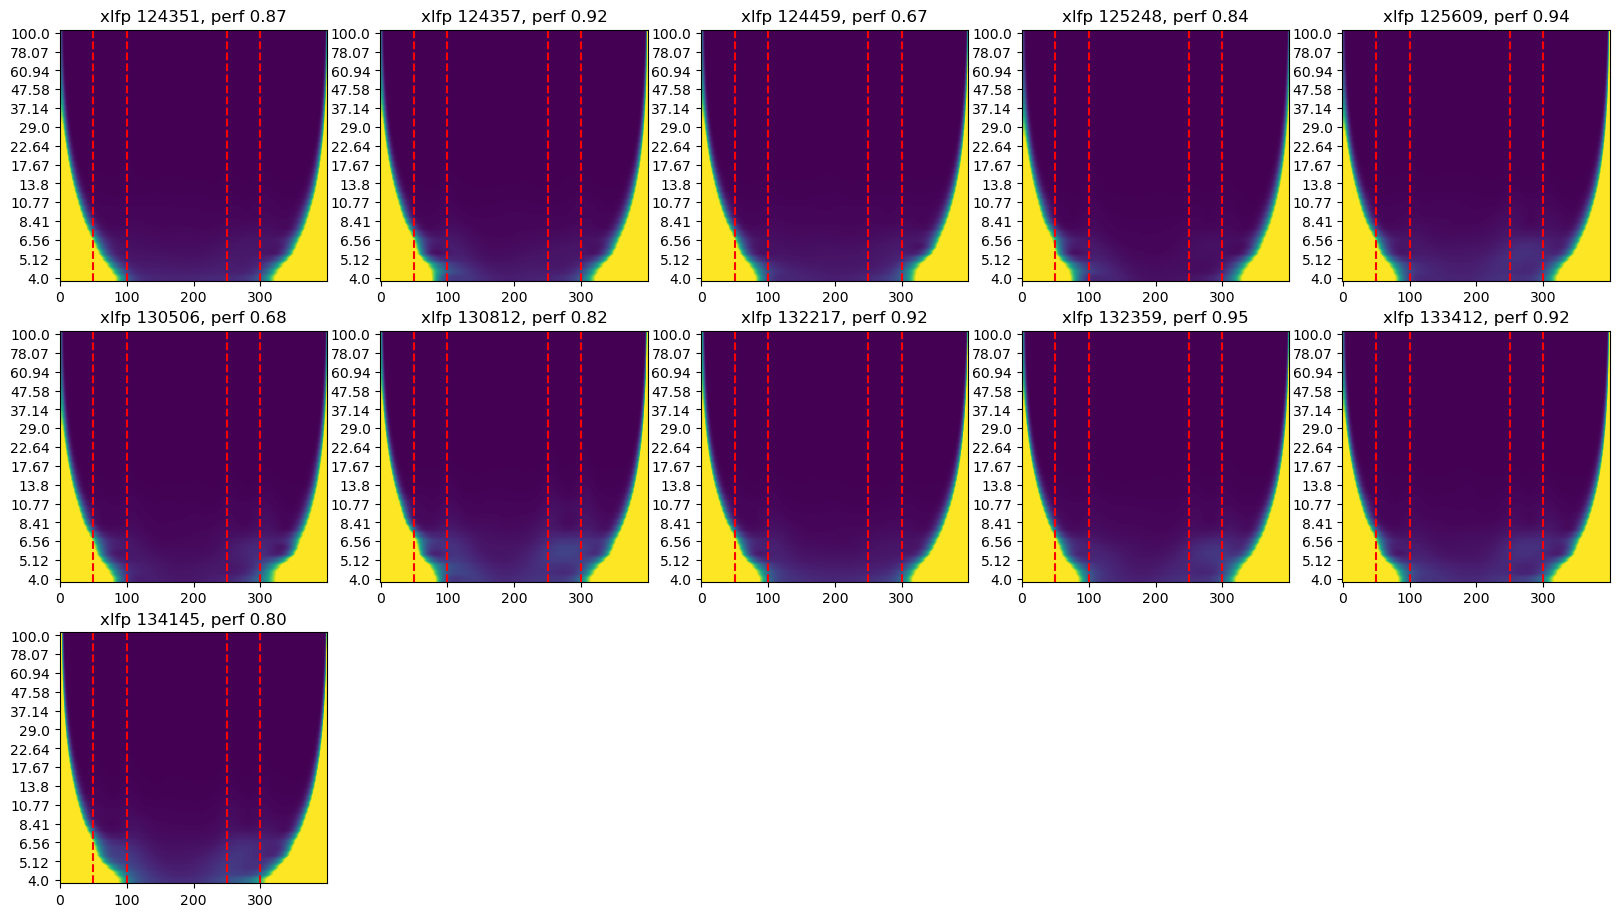

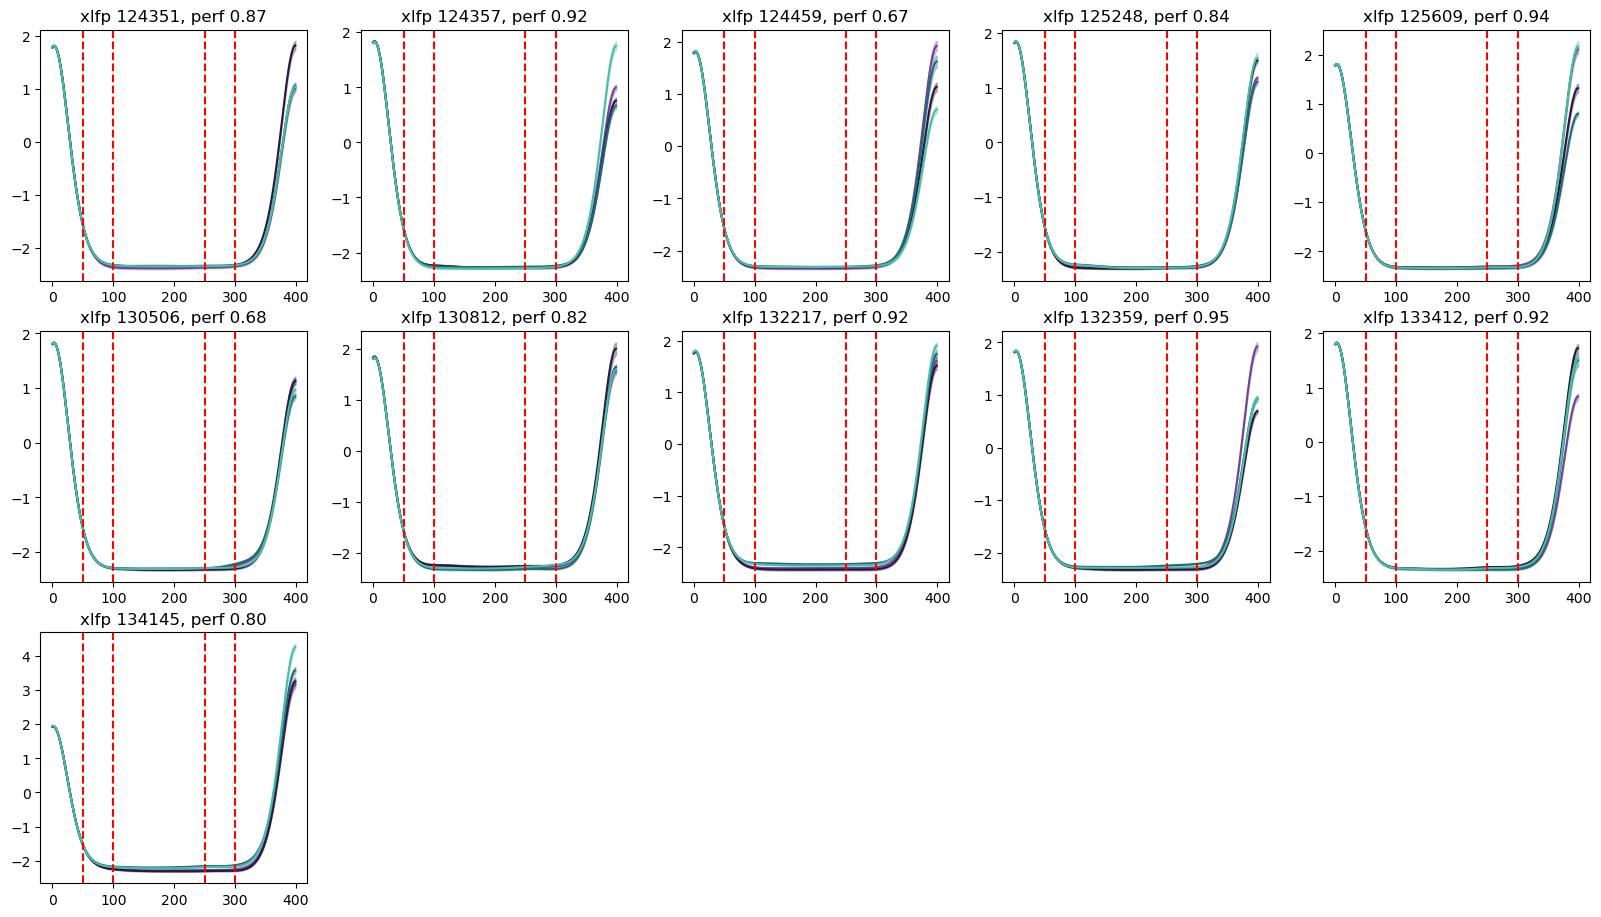

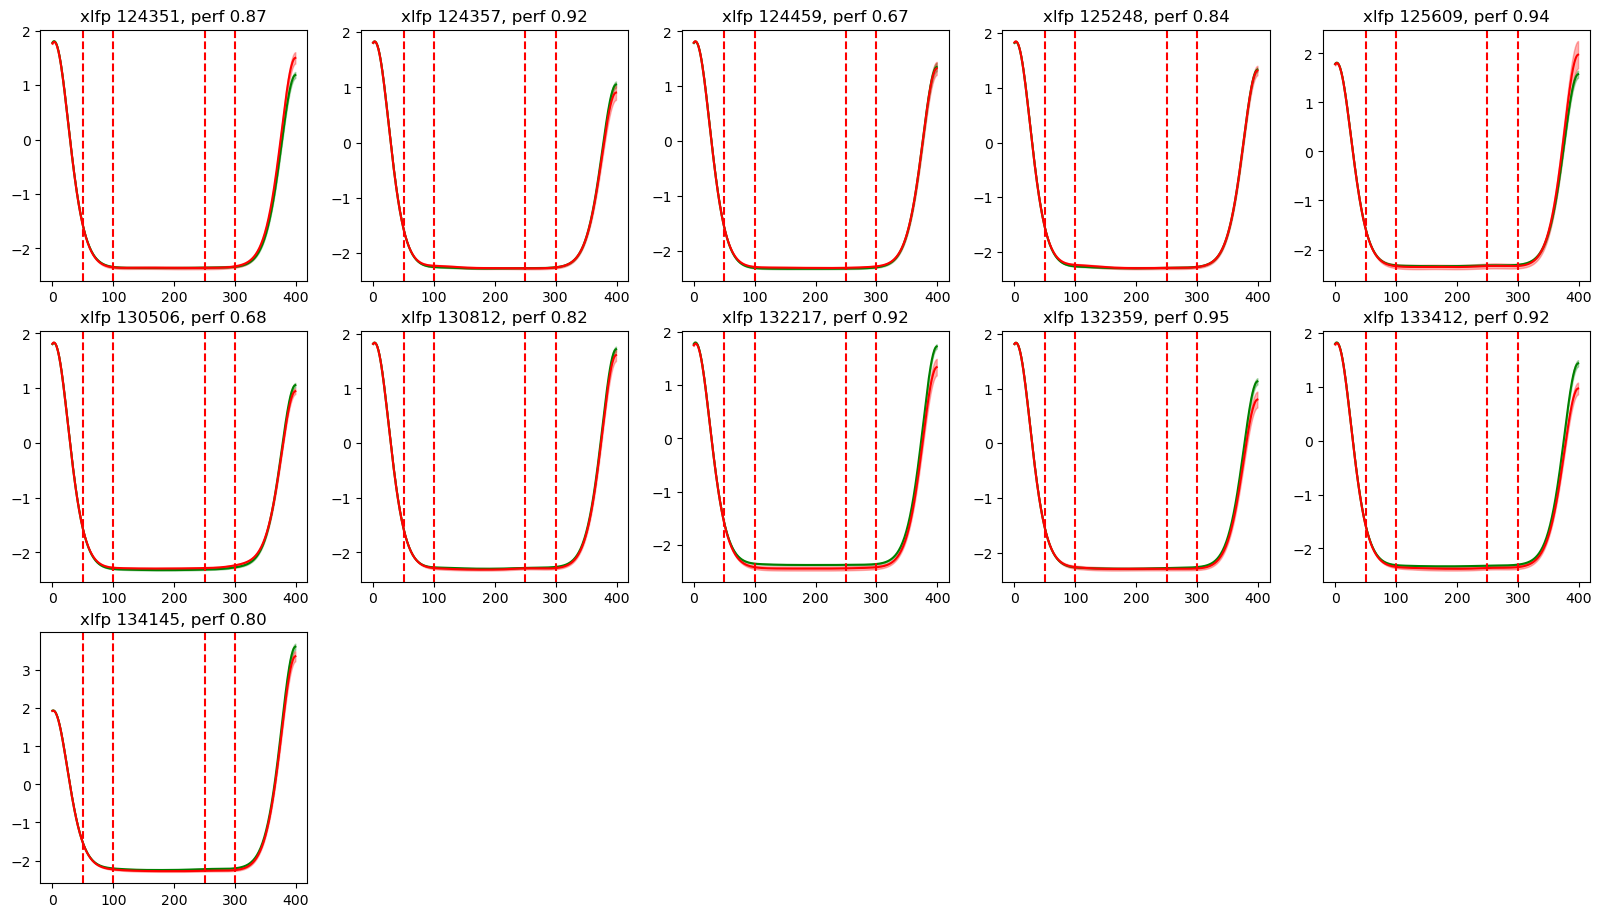

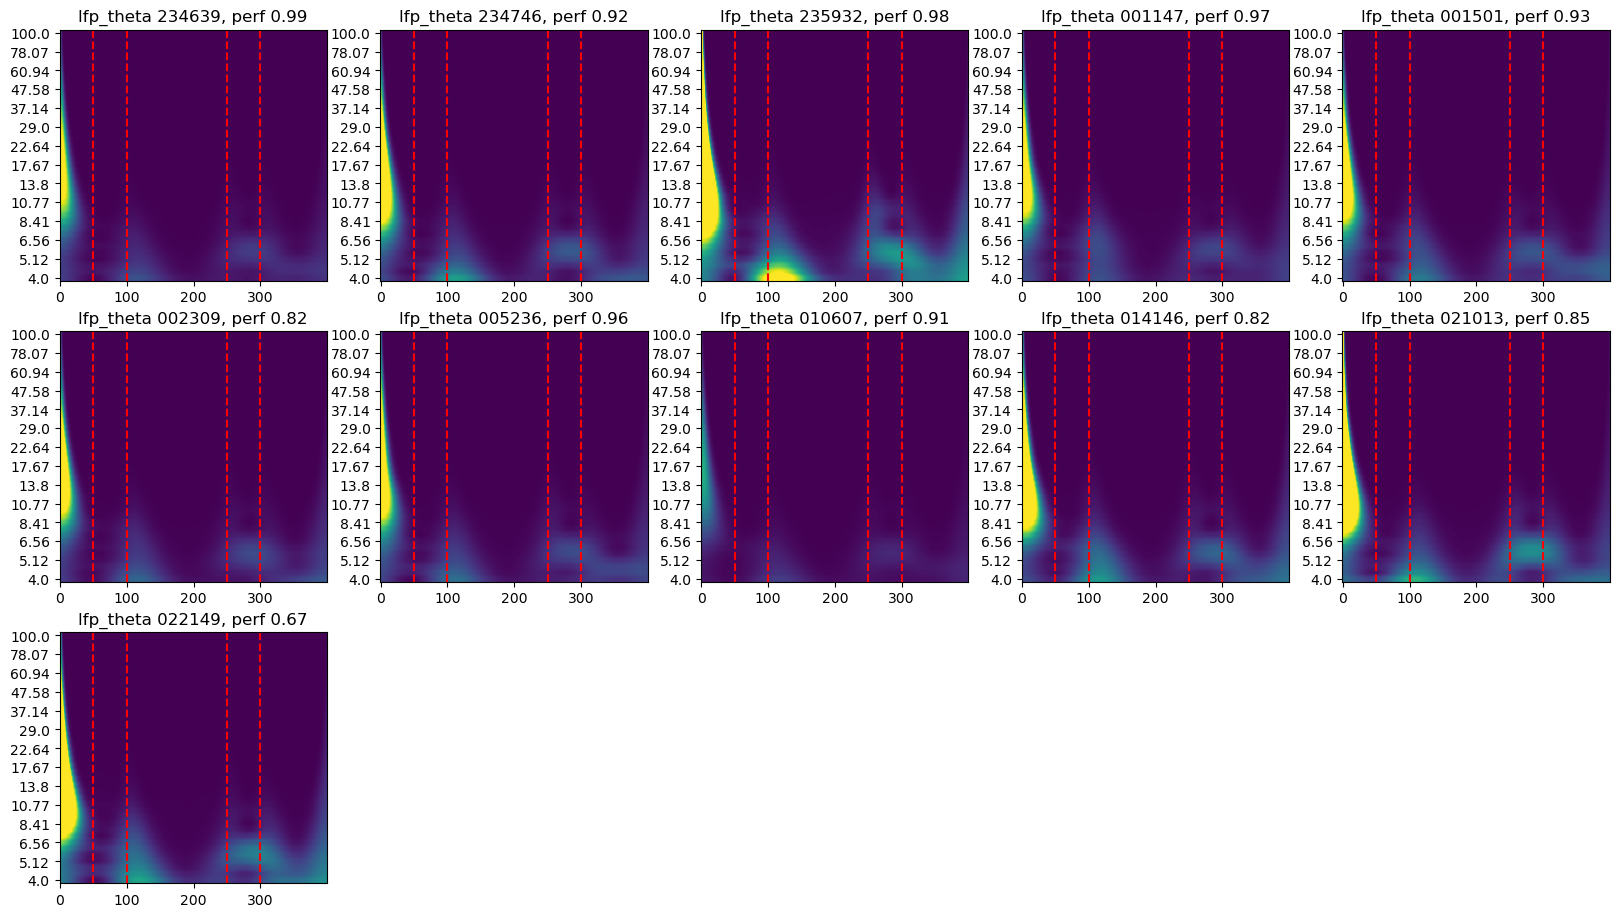

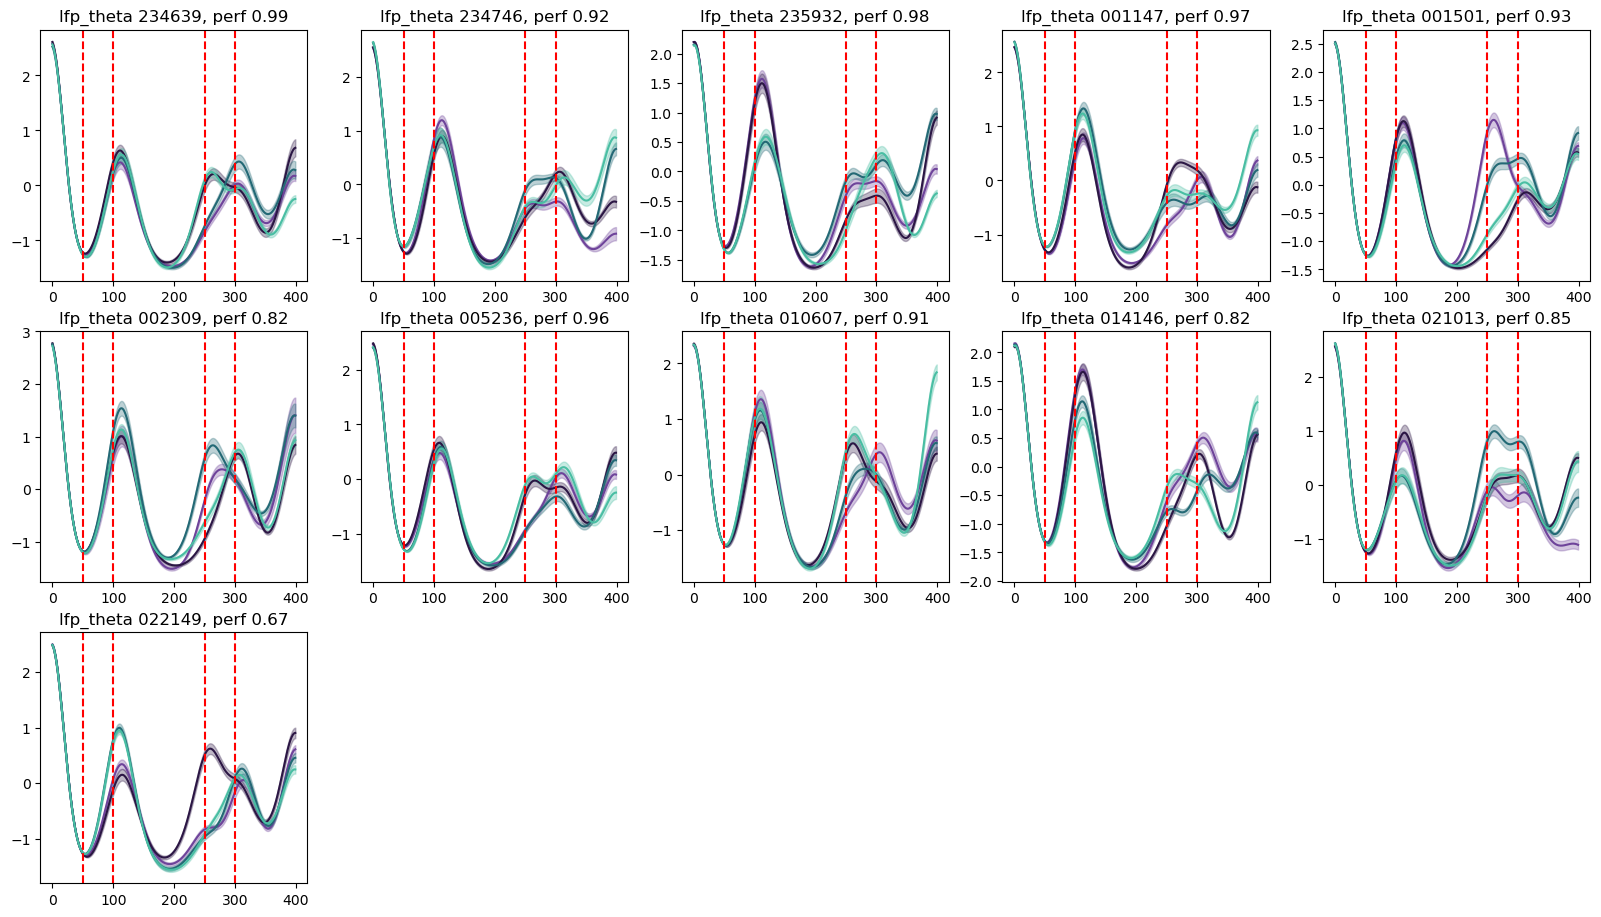

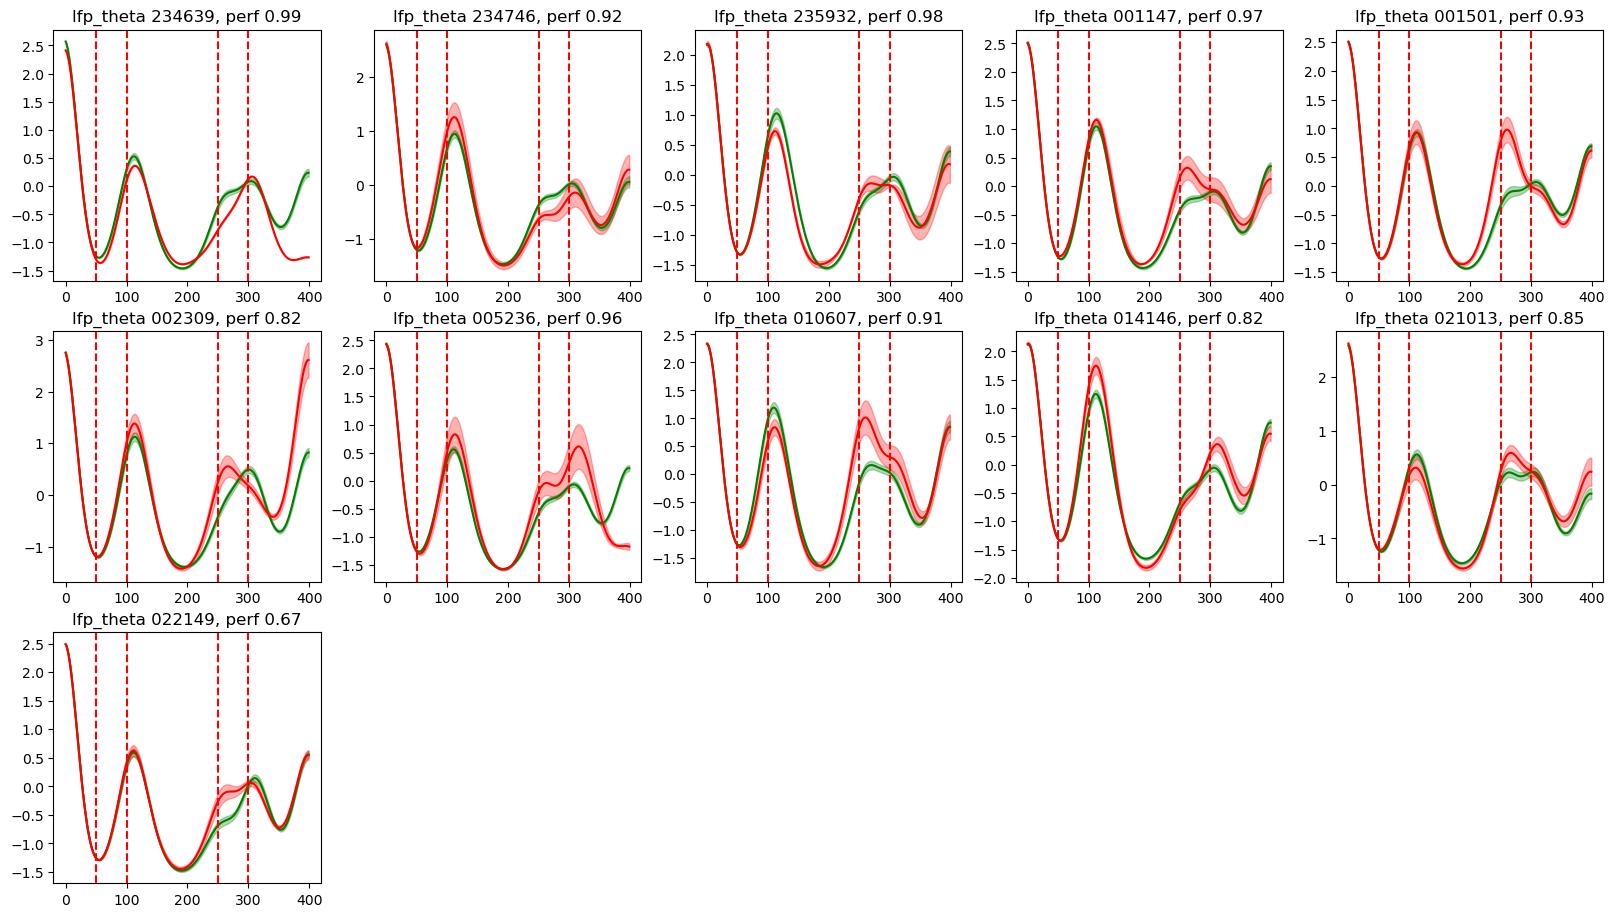

In [13]:
# make plots: spect, bandpower by trial type, bandpower by correct/incorrect

model_lists = [xlfp_model_list, lfp_theta_model_list] #, lfp_alpha_model_list]
model_dirs = [xlfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['xlfp', 'lfp_theta'] #, 'lfp_alpha']

for model_lists, model_dirs, model_list_names in zip(model_lists, model_dirs, model_list_names):
    model_list = model_lists
    model_dir = model_dirs
    model_list_name = model_list_names

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')
    
    # create figure
    fig1 = plt.figure(figsize=(20, 15)) # spectrogram
    fig2 = plt.figure(figsize=(20, 15)) # band power, split by trial type
    fig3 = plt.figure(figsize=(20, 15)) # band power, split by correct/incorrect

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict.pkl'), 'rb'))
        bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict.pkl'), 'rb'))
        
        # calculate spectrogram data for all trials
        n_freqs = 40
        n_trials = neural_dict['epsp'].shape[0]

        trial_powerband = np.zeros((n_trials, settings['T'])) # [N, T]
        avg_power = np.zeros((settings['T'], n_freqs)) # [T, F]
        for i in range(n_trials):
            trial_power, freqs, trial_powerband[i, :] = compute_lfp_power_np(neural_dict['epsp'][i, :], settings)
            avg_power += trial_power / n_trials
            
        # first plot spectrogram
        ax1 = fig1.add_subplot(4, 5, model_list.index(model_name)+1)
        ax1.imshow(avg_power.T, aspect='auto', origin='lower',
               vmin=0, vmax=1.2)
        ax1.set_yticks(np.arange(0, 40, 3), np.round(freqs[::3], 2))
        # ax1.colorbar(label='Power')
        ax1.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
        ax1.axvline(x=settings['stim_on'], color='r', linestyle='--')
        ax1.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
        ax1.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
        ax1.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')
        
        # then plot band power, split by trial type
        ax2 = fig2.add_subplot(4, 5, model_list.index(model_name)+1)
        stims, colors = ld.get_trialtype_colors()
        trial_types, trial_idxs = np.unique(np.array(bhv_dict['trial_type']), axis=0, return_inverse=True)
        for i, trial_type in enumerate(trial_types):
            trials_idx = (trial_idxs == i)
            powerband_mean = np.mean(trial_powerband[trials_idx, :], axis=0)
            powerband_sem = np.std(trial_powerband[trials_idx, :], axis=0) / np.sqrt(np.sum(trials_idx))
            ax2.plot(powerband_mean, color=colors[i])#, label=stims[i])
            ax2.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color=colors[i], alpha=0.3)
        ax2.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
        ax2.axvline(x=settings['stim_on'], color='r', linestyle='--')
        ax2.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
        ax2.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
        ax2.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')
        
        # finally plot band power, split by correct/incorrect
        ax3 = fig3.add_subplot(4, 5, model_list.index(model_name)+1)
        correct_trials = (np.array(bhv_dict['perf']) == 1)
        incorrect_trials = (np.array(bhv_dict['perf']) == 0)
        powerband_mean = np.mean(trial_powerband[correct_trials, :], axis=0)
        powerband_sem = np.std(trial_powerband[correct_trials, :], axis=0) / np.sqrt(np.sum(correct_trials))
        ax3.plot(powerband_mean, color='g', label='correct')
        ax3.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='g', alpha=0.3)
        powerband_mean = np.mean(trial_powerband[incorrect_trials, :], axis=0)
        powerband_sem = np.std(trial_powerband[incorrect_trials, :], axis=0) / np.sqrt(np.sum(incorrect_trials))
        ax3.plot(powerband_mean, color='r', label='incorrect')
        ax3.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='r', alpha=0.3)
        ax3.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
        ax3.axvline(x=settings['stim_on'], color='r', linestyle='--')
        ax3.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
        ax3.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
        ax3.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')



Processing model type: xlfp, number of models: 11
Processing model type: lfp_theta, number of models: 11


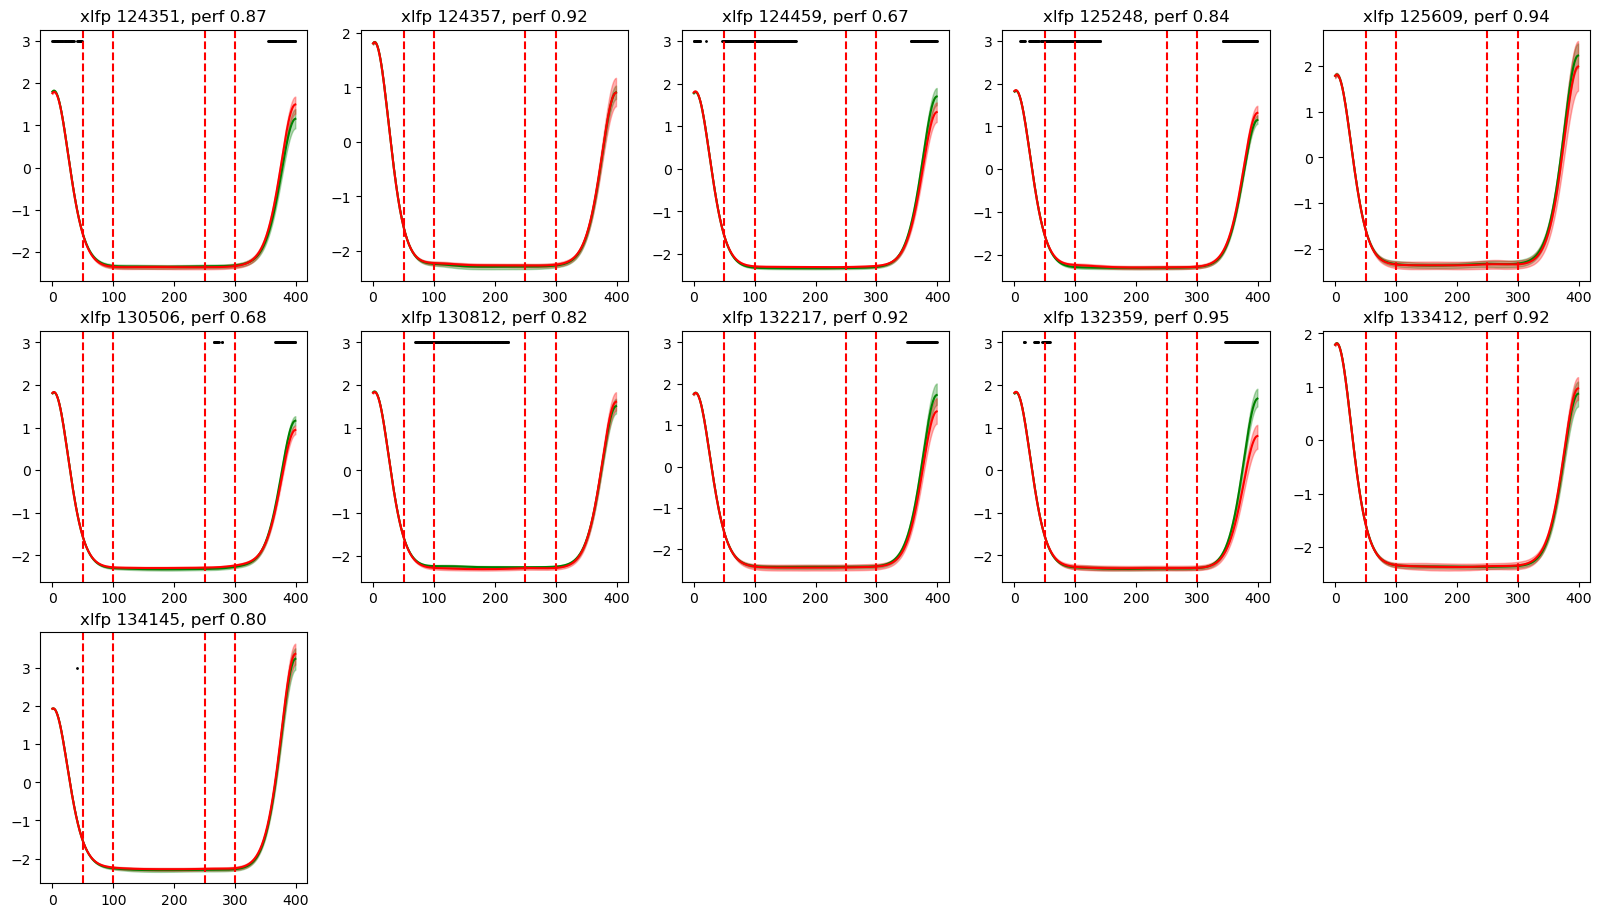

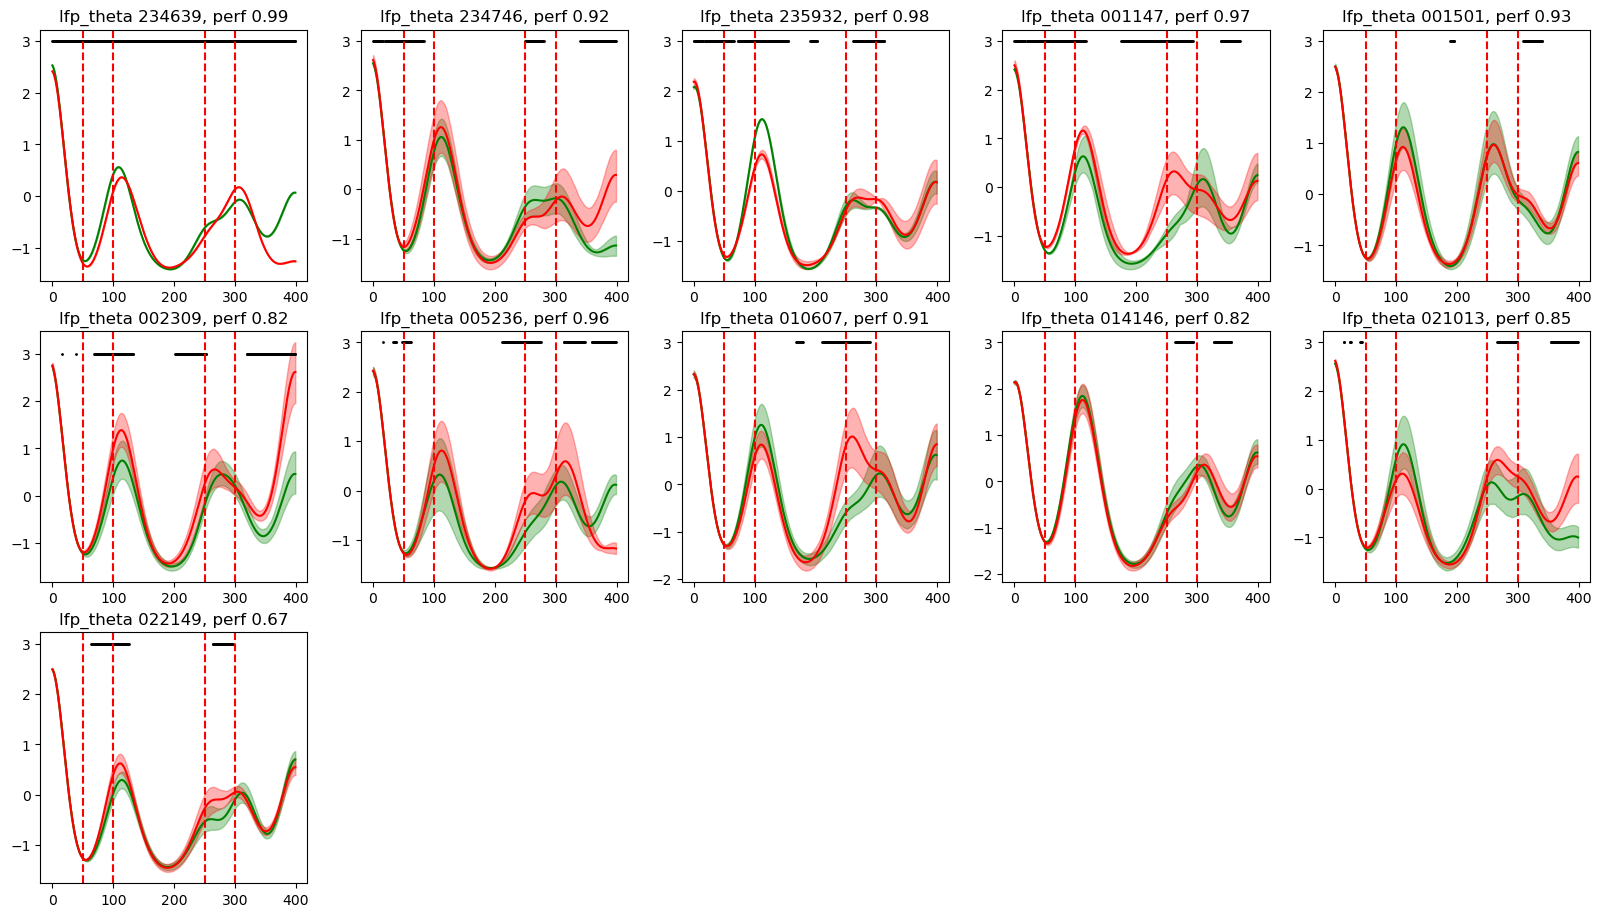

In [14]:
# make plot: bandpower by correct/incorrect w bootstrapping

from bootstrap_method import fnc_time_bootstrap_optimized_retX

random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)

model_lists = [xlfp_model_list, lfp_theta_model_list] #, lfp_alpha_model_list]
model_dirs = [xlfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['xlfp', 'lfp_theta'] #, 'lfp_alpha']

for model_lists, model_dirs, model_list_names in zip(model_lists, model_dirs, model_list_names):
    model_list = model_lists
    model_dir = model_dirs
    model_list_name = model_list_names

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')
    
    # create figure
    fig = plt.figure(figsize=(20, 15)) # band power, split by correct/incorrect

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict.pkl'), 'rb'))
        bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict.pkl'), 'rb'))
        
        # calculate spectrogram data for all trials
        n_freqs = 40
        n_trials = neural_dict['epsp'].shape[0]

        trial_powerband = np.zeros((n_trials, settings['T'])) # [N, T]
        avg_power = np.zeros((settings['T'], n_freqs)) # [T, F]
        for i in range(n_trials):
            trial_power, freqs, trial_powerband[i, :] = compute_lfp_power_np(neural_dict['epsp'][i, :], settings)
            avg_power += trial_power / n_trials
            
        # finally plot band power, split by correct/incorrect
        ax = fig.add_subplot(4, 5, model_list.index(model_name)+1)
        correct_trials = (np.array(bhv_dict['perf']) == 1)
        incorrect_trials = (np.array(bhv_dict['perf']) == 0)
        
        t1_avg, t1_CI, t2_avg, t2_CI, diff_avg, diff_CI, p_diff = fnc_time_bootstrap_optimized_retX(trial_powerband[correct_trials, :], 
                                                                                               trial_powerband[incorrect_trials, :], 
                                                                                               nboot, CI_int, n_jobs=-1, random_seed=None)
        
        ax.plot(t1_avg.mean(axis=1), color='g', label='correct')
        ax.fill_between(np.arange(settings['T']), t1_CI[:,0], t1_CI[:,1], color='g', alpha=0.3)
        powerband_mean = np.mean(trial_powerband[incorrect_trials, :], axis=0)
        powerband_sem = np.std(trial_powerband[incorrect_trials, :], axis=0) / np.sqrt(np.sum(incorrect_trials))
        ax.plot(t2_avg.mean(axis=1), color='r', label='incorrect')
        ax.fill_between(np.arange(settings['T']), t2_CI[:,0], t2_CI[:,1], color='r', alpha=0.3)
        # plot bar for significant difference
        sig_idx = np.where(p_diff < 0.05)[0]
        ax.scatter(sig_idx, np.ones_like(sig_idx)*3, color='k', s=1)
        ax.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
        ax.axvline(x=settings['stim_on'], color='r', linestyle='--')
        ax.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
        ax.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
        ax.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')



Processing model type: xlfp, number of models: 11


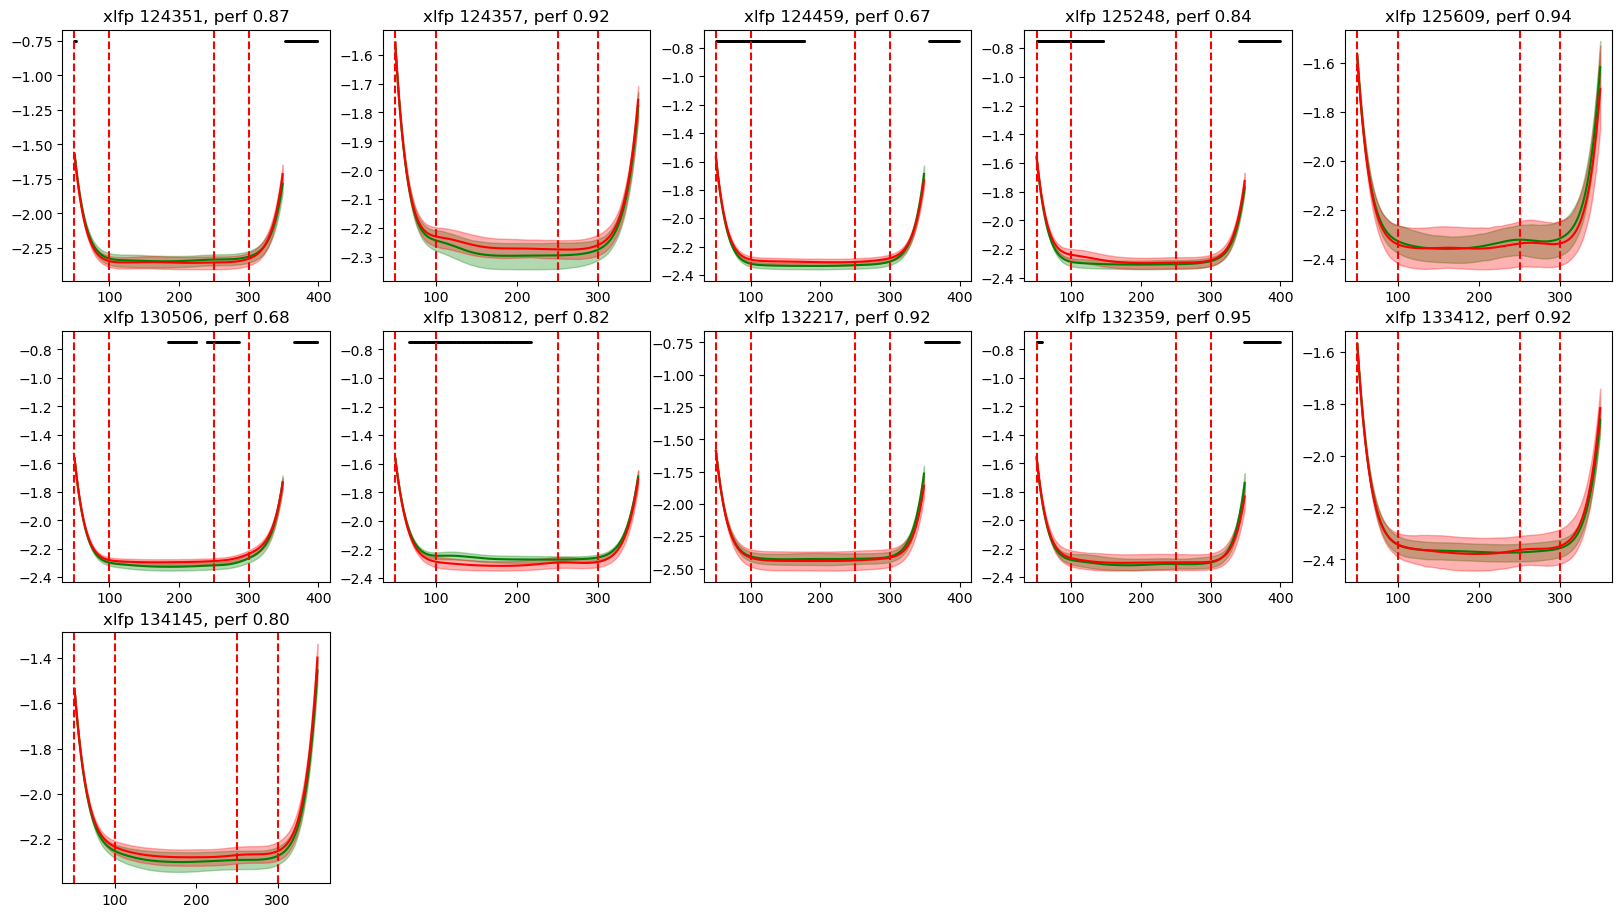

Processing model type: lfp_theta, number of models: 11


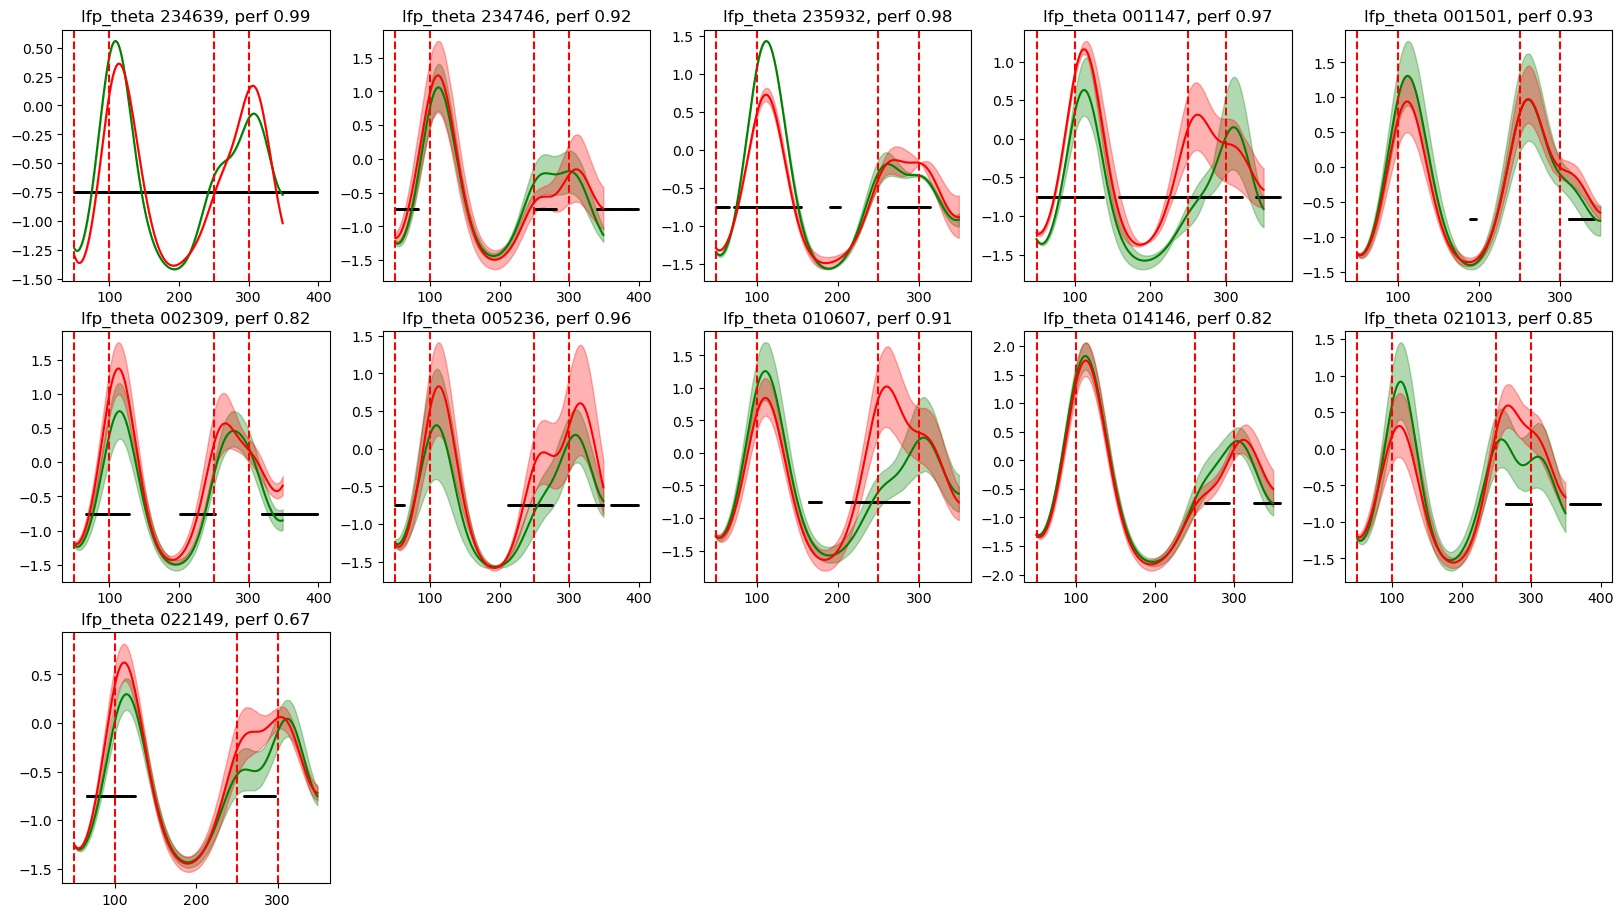

In [16]:
# make plot: bandpower by correct/incorrect w bootstrapping (cutting x-axis)

from bootstrap_method import fnc_time_bootstrap_optimized_retX

random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)

model_lists = [xlfp_model_list, lfp_theta_model_list] #, lfp_alpha_model_list]
model_dirs = [xlfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['xlfp', 'lfp_theta'] #, 'lfp_alpha']

for model_lists, model_dirs, model_list_names in zip(model_lists, model_dirs, model_list_names):
    model_list = model_lists
    model_dir = model_dirs
    model_list_name = model_list_names

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')
    
    # create figure
    fig = plt.figure(figsize=(20, 15)) # band power, split by correct/incorrect

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict.pkl'), 'rb'))
        bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict.pkl'), 'rb'))
        
        # calculate spectrogram data for all trials
        n_freqs = 40
        n_trials = neural_dict['epsp'].shape[0]

        trial_powerband = np.zeros((n_trials, settings['T'])) # [N, T]
        avg_power = np.zeros((settings['T'], n_freqs)) # [T, F]
        for i in range(n_trials):
            trial_power, freqs, trial_powerband[i, :] = compute_lfp_power_np(neural_dict['epsp'][i, :], settings)
            avg_power += trial_power / n_trials
            
        # finally plot band power, split by correct/incorrect
        ax = fig.add_subplot(4, 5, model_list.index(model_name)+1)
        correct_trials = (np.array(bhv_dict['perf']) == 1)
        incorrect_trials = (np.array(bhv_dict['perf']) == 0)
        
        t1_avg, t1_CI, t2_avg, t2_CI, diff_avg, diff_CI, p_diff = fnc_time_bootstrap_optimized_retX(trial_powerband[correct_trials, :], 
                                                                                               trial_powerband[incorrect_trials, :], 
                                                                                               nboot, CI_int, n_jobs=-1, random_seed=None)
        plot_x = np.arange(50, 350)
        ax.plot(plot_x, t1_avg.mean(axis=1)[plot_x], color='g', label='correct')
        ax.fill_between(plot_x, t1_CI[plot_x,0], t1_CI[plot_x,1], color='g', alpha=0.3)
        ax.plot(plot_x, t2_avg.mean(axis=1)[plot_x], color='r', label='incorrect')
        ax.fill_between(plot_x, t2_CI[plot_x,0], t2_CI[plot_x,1], color='r', alpha=0.3)
        # plot bar for significant difference
        sig_idx = np.where(p_diff < 0.05)[0]
        sig_idx = sig_idx[(sig_idx>=50) & (sig_idx<=450)]
        ax.scatter(sig_idx, np.ones_like(sig_idx)*-0.75, color='k', s=1)
        ax.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
        ax.axvline(x=settings['stim_on'], color='r', linestyle='--')
        ax.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
        ax.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
        ax.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')
    
    plt.show()



### extend maintenance

#### 50 to 400

In [6]:
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
import model

Instructions for updating:
non-resource variables are not supported in the long term


In [7]:
settings = {
        'T': 600, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4, 8], # theta
        'fs': 200,
        'task': 'xor', # task name
        }

In [6]:
# lfp models (lfp) — theta

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
# lfp_model_list = os.listdir(lfp_model_dir)
# lfp_model_list = [m for m in lfp_model_list if m.endswith('.mat') and m.]
lfp_theta_model_list = ld.find_files_keywords(lfp_model_dir, ['Jitter', '4.0_8.0', '.mat'])
# remove directories 
lfp_theta_model_list = [m.split('/')[-1] for m in lfp_theta_model_list]
lfp_theta_model_list.sort()

# remove the last model, which was trained with different parameters
lfp_theta_model_list = lfp_theta_model_list[:-1]
# print(lfp_theta_model_list)
print(len(lfp_theta_model_list))

perfs = []
train_trials = []
for i, model_name in enumerate(lfp_theta_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

11
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_234639.mat, Test perf: 0.99, Train trials: 14501
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_234746.mat, Test perf: 0.99, Train trials: 15101
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_235932.mat, Test perf: 0.98, Train trials: 22901
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_001147.mat, Test perf: 0.99, Train trials: 14401
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_001501.mat, Test perf: 0.98, Train trials: 16001
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_002309.mat, Test perf: 1.0, Train trials: 13401
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_005236.mat, Test perf: 0.97, Train trials: 17401
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_010607.mat, Test perf: 1.0, Train trials: 7801
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_014146.mat, Test perf: 1.0, Train trials: 12101
Model: Task_xor_N_200_Jitter_10_10_LFP

In [ ]:
# model eval on 100 random trials — no LFP

n_trials = 100
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7

model_dir = xlfp_model_dir
model_list = xlfp_model_list

xlfp_model_perfs = np.zeros(len(model_list))
for n_model, model_name in enumerate(model_list):
    
    eval_perf = np.zeros(n_trials)
    eval_os = np.zeros((n_trials, settings['T']))

    for i in range(n_trials):
        eval_u, eval_label = model.generate_input_stim_xor(settings)
        _, _, eval_o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=eval_u)
        eval_os[i, :] = np.squeeze(eval_o)
        if eval_label == 'same':
            if np.max(eval_o[resp_onset:]) > eval_amp_threshold:
                eval_perf[i] = 1
        else:
            if np.min(eval_o[resp_onset:]) < -eval_amp_threshold:
                eval_perf[i] = 1

    eval_perf_mean = np.nanmean(eval_perf)
    print("Performance: %.2f"%(eval_perf_mean))

    xlfp_model_perfs[n_model] = eval_perf_mean


Performance: 0.60
Performance: 0.76
Performance: 0.53
Performance: 0.44
Performance: 0.94
Performance: 0.25
Performance: 0.55
Performance: 0.79
Performance: 0.82
Performance: 0.86


Mann-Whitney U test statistic: 123.00, p-value: 0.92


/tmp/ipykernel_598571/1948864179.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lfp_model_perfs, xlfp_model_perfs], labels=['LFP', 'X-LFP'])


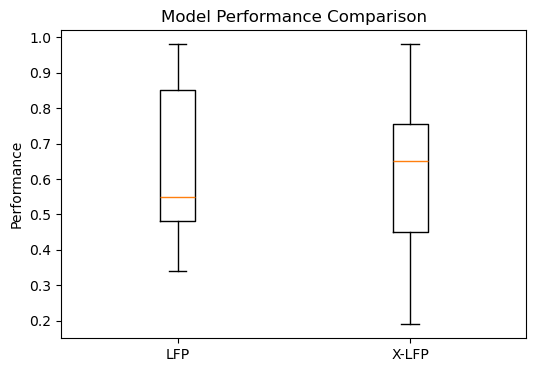

In [ ]:
# box plots comparing model perfs from both groups, with stats

plt.figure(figsize=(6,4))
plt.boxplot([lfp_model_perfs, xlfp_model_perfs], labels=['LFP', 'X-LFP'])

from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(lfp_model_perfs, xlfp_model_perfs)
print("Mann-Whitney U test statistic: %.2f, p-value: %.2f" % (stat, p))

if p<0.05:
    plt.text(1.2, 0.1, '*', fontsize=20, ha='center')

plt.ylabel('Performance')
plt.title('Model Performance Comparison')
# plt.grid()
plt.show()

## plot the generated data for delay=400

In [4]:
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4, 8], # theta
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor', # task name
        }

#### jitter=10

In [10]:
# lfp models (lfp) — theta

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
# lfp_model_list = os.listdir(lfp_model_dir)
# lfp_model_list = [m for m in lfp_model_list if m.endswith('.mat') and m.]
lfp_theta_model_list = ld.find_files_keywords(lfp_model_dir, ['Jitter', '4.0_8.0', '.mat'])
# remove directories 
lfp_theta_model_list = [m.split('/')[-1] for m in lfp_theta_model_list]
lfp_theta_model_list.sort()

# remove the last model, which was trained with different parameters
lfp_theta_model_list = lfp_theta_model_list[:-1]
# print(lfp_theta_model_list)
print(len(lfp_theta_model_list))

perfs = []
train_trials = []
for i, model_name in enumerate(lfp_theta_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

43
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_234639.mat, Test perf: 0.99, Train trials: 14501
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_234746.mat, Test perf: 0.99, Train trials: 15101
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_03_235932.mat, Test perf: 0.98, Train trials: 22901
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_001147.mat, Test perf: 0.99, Train trials: 14401
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_001501.mat, Test perf: 0.98, Train trials: 16001
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_002309.mat, Test perf: 1.0, Train trials: 13401
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_005236.mat, Test perf: 0.97, Train trials: 17401
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_010607.mat, Test perf: 1.0, Train trials: 7801
Model: Task_xor_N_200_Jitter_10_10_LFP_4.0_8.0_2025_09_04_014146.mat, Test perf: 1.0, Train trials: 12101
Model: Task_xor_N_200_Jitter_10_10_LFP

Mann-Whitney U test statistic: 1657.50, p-value: 0.00


/tmp/ipykernel_303216/2054870674.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([perfs, perfs_delay400], labels=['delay 50', 'delay 400'])


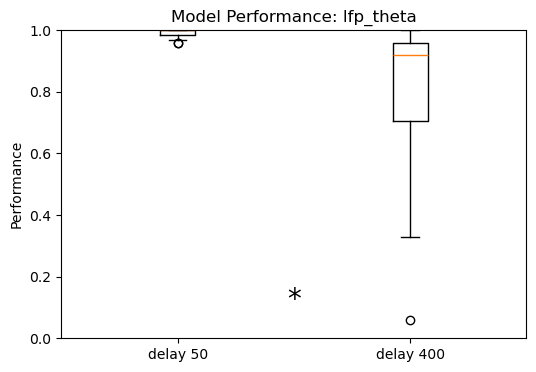

In [ ]:
# performance plots, jitter=10

model_list = lfp_theta_model_list
model_dir = lfp_model_dir
model_list_name = 'lfp_theta'

# create figure
fig = plt.figure(figsize=(6, 4))

perfs_delay400 = []
for model_name in model_list:
    # print(f"\nModel: {model_name}")
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    
    # get neural and behavioral data
    # neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict_delay400.pkl'), 'rb'))
    bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict_delay400.pkl'), 'rb'))
    perfs_delay400.append(np.mean(bhv_dict['perf']))
    
# plot perfs and perfs_delay400
plt.boxplot([perfs, perfs_delay400], labels=['delay 50', 'delay 400'])
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(perfs, perfs_delay400)
print("Mann-Whitney U test statistic: %.2f, p-value: %.2f" % (stat, p))
if p<0.05:
    plt.text(1.5, 0.1, '*', fontsize=20, ha='center')
plt.ylabel('Performance')
plt.title(f'Model Performance: {model_list_name}')
plt.ylim([0, 1])
plt.show()

Mann-Whitney U test statistic: 4.00, p-value: 0.22


/tmp/ipykernel_555042/3366226835.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([perfs, perfs_delay400], labels=['delay 50', 'delay 400'])


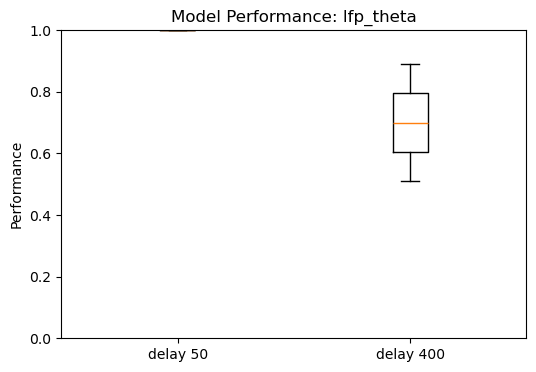

In [9]:
# performance plots, jitter=10

model_list = lfp_theta_model_list
model_dir = lfp_model_dir
model_list_name = 'lfp_theta'

# create figure
fig = plt.figure(figsize=(6, 4))

perfs_delay400 = []
for model_name in model_list:
    # print(f"\nModel: {model_name}")
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    
    # get neural and behavioral data
    # neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict_delay400.pkl'), 'rb'))
    bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict_delay400.pkl'), 'rb'))
    perfs_delay400.append(np.mean(bhv_dict['perf']))
    
# plot perfs and perfs_delay400
plt.boxplot([perfs, perfs_delay400], labels=['delay 50', 'delay 400'])
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(perfs, perfs_delay400)
print("Mann-Whitney U test statistic: %.2f, p-value: %.2f" % (stat, p))
if p<0.05:
    plt.text(1.5, 0.1, '*', fontsize=20, ha='center')
plt.ylabel('Performance')
plt.title(f'Model Performance: {model_list_name}')
plt.ylim([0, 1])
plt.show()

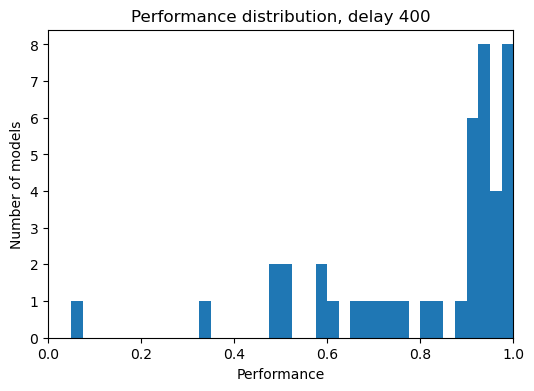

In [16]:
# histogram of perfs_delay400

plt.figure(figsize=(6,4))
plt.hist(perfs_delay400, bins=40, range=(0,1))
plt.xlabel('Performance')
plt.ylabel('Number of models')
plt.title('Performance distribution, delay 400')
plt.xlim([0, 1])
plt.show()

PCA explained variance: [0.67252061 0.11538475 0.07768218], total: 0.8655875328233176
PCA explained variance: [0.39286362 0.22520679 0.17313737], total: 0.7912077841102207
PCA explained variance: [0.59797289 0.11825854 0.07816668], total: 0.7943981093024237
PCA explained variance: [0.65147919 0.10679162 0.06291871], total: 0.8211895097467615
PCA explained variance: [0.67673957 0.09645045 0.06455079], total: 0.8377408035760652
PCA explained variance: [0.4576646  0.30782008 0.08811866], total: 0.8536033439673726
PCA explained variance: [0.73367128 0.0907327  0.05464377], total: 0.8790477446849395
PCA explained variance: [0.43252704 0.22097822 0.17113961], total: 0.8246448668227724
PCA explained variance: [0.67224918 0.11145779 0.06124737], total: 0.8449543412185655
PCA explained variance: [0.58658179 0.13622995 0.08671948], total: 0.8095312082082569
PCA explained variance: [0.59584368 0.11643841 0.07588144], total: 0.7881635319532133


Text(0.5, 0.98, 'Population trajectory PCA (correct only), model type: lfp_theta')

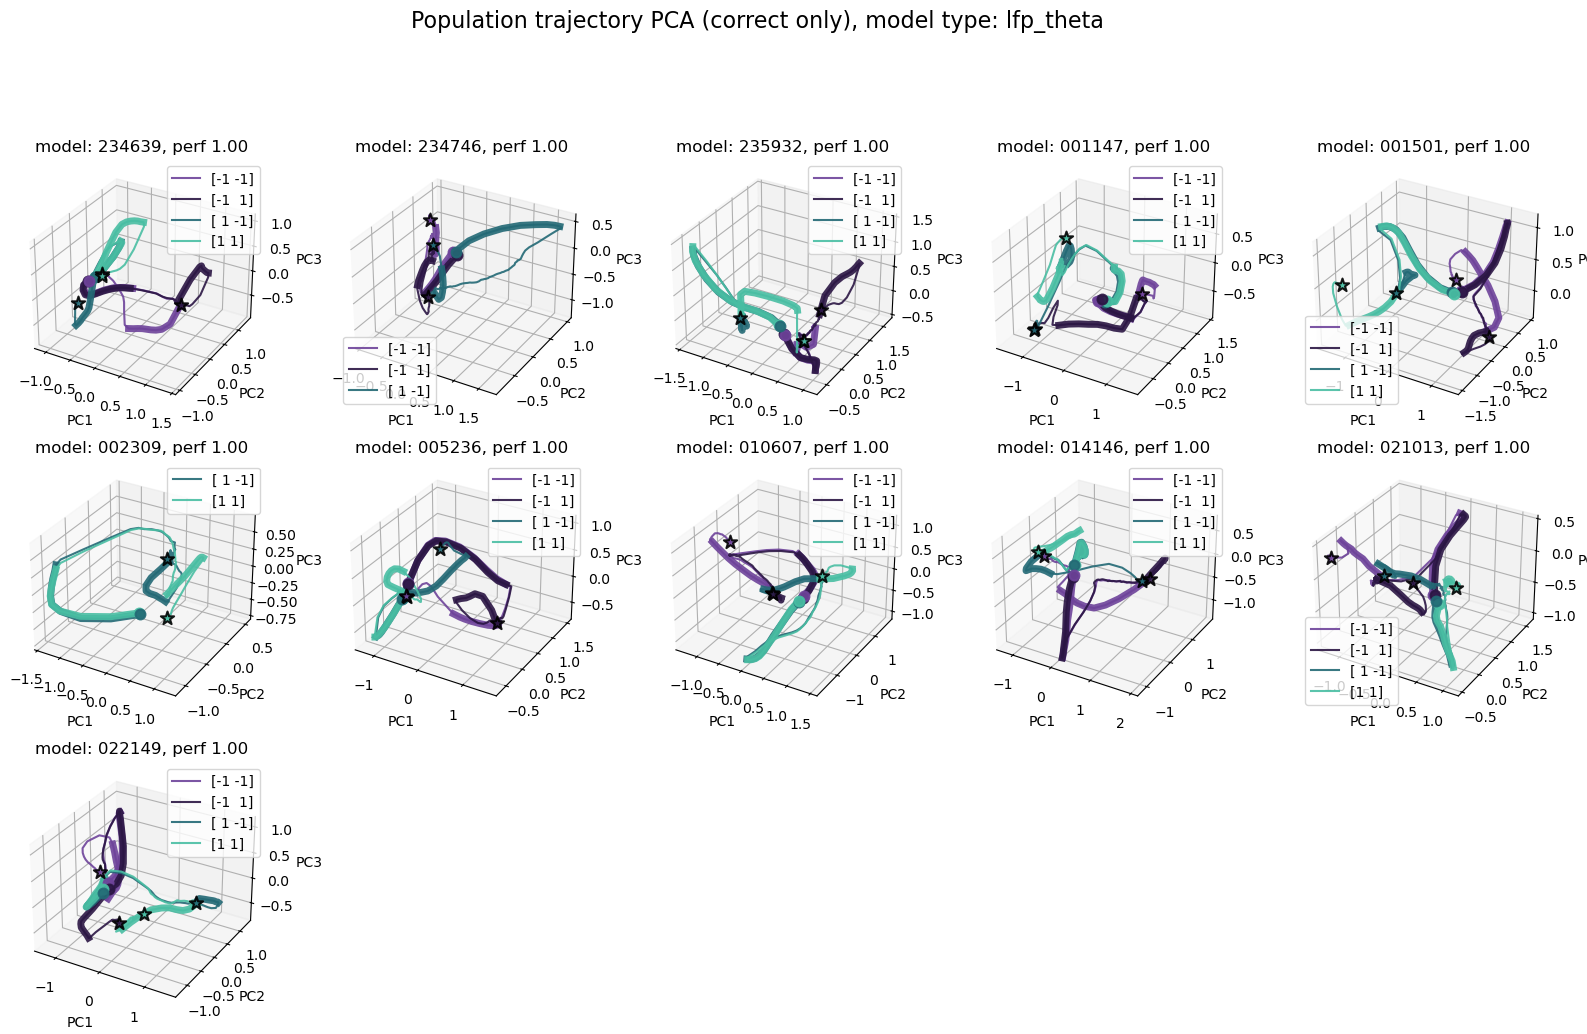

In [8]:
# trajectories for correct trials only

model_list = lfp_theta_model_list
model_dir = lfp_model_dir
model_list_name = 'lfp_theta'

# create figure
fig = plt.figure(figsize=(20, 15))

for model_name in model_list:
    # print(f"\nModel: {model_name}")
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    
    # get neural and behavioral data
    neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict_delay400.pkl'), 'rb'))
    bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict_delay400.pkl'), 'rb'))
    correct_trials = np.where(bhv_dict['perf'] == 1)[0]
    neural_dict['r'] = neural_dict['r'][correct_trials, :, :]
    bhv_dict['trial_type'] = np.array(bhv_dict['trial_type'])[correct_trials]
    bhv_dict['perf'] = np.array(bhv_dict['perf'])[correct_trials]
    
    ax = fig.add_subplot(4, 5, model_list.index(model_name)+1, projection='3d')
    ax, _ = pu.plot_trajectory_pca(rates_data=neural_dict['r'], trial_labels=np.array(bhv_dict['trial_type']), 
                    settings=settings, cut_off=50, plot=1, ds=5, smooth=2, ax=ax,
                    title=f'model: {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')

fig.suptitle(f'Population trajectory PCA (correct only), model type: {model_list_name}', fontsize=16)

##### plot EPSP

In [6]:
# spect calculation function in numpy

def compute_lfp_power_np(epsp, settings):
    """
    Compute band-limited z-scored LFP power using Morlet wavelets (NumPy version).

    Parameters
    ----------
    epsp : list or np.ndarray
        Length-T list or array of scalar values (e.g., EPSP signal).
    settings : dict
        Dictionary containing:
            - 'T': int, length of the signal
            - 'fs': float, sampling frequency in Hz
            - 'lfp_power_target': list or tuple of [low_freq, high_freq]
            - 'stim_on': int, time index of stimulus onset

    Returns
    -------
    lfp_power_z : np.ndarray
        Z-scored LFP power in the target frequency band. Shape [T]
    """
    # --- settings ---
    T = settings['T']
    fs = settings['fs']
    dt = 1.0 / fs
    fmin, fmax = 4.0, 100.0
    num_freqs = 40
    band_lo, band_hi = settings['lfp_power_target']
    stim_on = settings['stim_on']

    # --- epsp input processing ---
    epsp_vec = np.squeeze(np.stack(epsp, axis=0))  # [T]
    epsp_sig = np.reshape(epsp_vec, [1, T, 1])      # [1, T, 1]

    # --- frequencies & scales ---
    freqs = np.exp(np.linspace(np.log(fmin), np.log(fmax), num_freqs))
    fc = 0.8125  # Morlet central frequency
    scales = fc / (freqs * dt)

    # --- build Morlet kernels ---
    K = 6.0
    f_low = fmin
    sigma_t_low = K / (2.0 * np.pi * f_low)
    half_width_sec = 4.0 * sigma_t_low
    kernel_len = int(round(2.0 * half_width_sec * fs) + 1)
    kernel_len = max(kernel_len, 31)

    t_idx = np.arange(kernel_len, dtype=np.float32) - (kernel_len - 1) / 2.0
    t_sec = t_idx / fs

    two_pi = 2.0 * np.pi
    sigma_t = K / (two_pi * freqs)  # [F]

    env = np.exp(-0.5 * (np.expand_dims(t_sec, 1) / np.expand_dims(sigma_t, 0))**2)
    phase = two_pi * np.expand_dims(t_sec, 1) * np.expand_dims(freqs, 0)
    cos_part = env * np.cos(phase)
    sin_part = env * np.sin(phase)

    # L2 normalize
    eps_norm = 1e-8
    norm = np.sqrt(np.sum(cos_part**2 + sin_part**2, axis=0, keepdims=True) + eps_norm)
    cos_part /= norm
    sin_part /= norm

    # Filters: [L, 1, F]
    cos_filt = np.expand_dims(cos_part, axis=1)
    sin_filt = np.expand_dims(sin_part, axis=1)

    # --- convolution with SAME padding ---
    def conv1d_same(x, filt):
        pad_len = filt.shape[0] // 2
        x_padded = np.pad(x, ((0, 0), (pad_len, pad_len), (0, 0)), mode='constant')
        output = np.zeros((x.shape[0], x.shape[1], filt.shape[2]))
        for f in range(filt.shape[2]):
            kernel = filt[:, 0, f][::-1]  # reverse for conv
            for b in range(x.shape[0]):
                output[b,:,f] = np.convolve(x_padded[b,:,0], kernel, mode='valid')
        return output

    real_coeff = conv1d_same(epsp_sig, cos_filt)  # [1, T, F]
    imag_coeff = conv1d_same(epsp_sig, sin_filt)  # [1, T, F]
    power = real_coeff**2 + imag_coeff**2        # [1, T, F]
    power = np.squeeze(power, axis=0)            # [T, F]

    # --- band selection ---
    band_mask = np.logical_and(freqs >= band_lo, freqs <= band_hi)
    band_mask_f = band_mask.astype(np.float32)
    denom = max(np.sum(band_mask_f), 1.0)
    band_power = np.dot(power, band_mask_f / denom)  # [T]

    # --- baseline z-scoring ---
    start = 10
    stop = int(stim_on)
    base_slice = band_power[start:stop]
    base_mean = np.mean(base_slice)
    base_std = np.std(base_slice) + 1e-8
    lfp_power_z = (band_power - base_mean) / base_std  # [T]

    return power, freqs, lfp_power_z


Processing model type: lfp_theta, number of models: 11


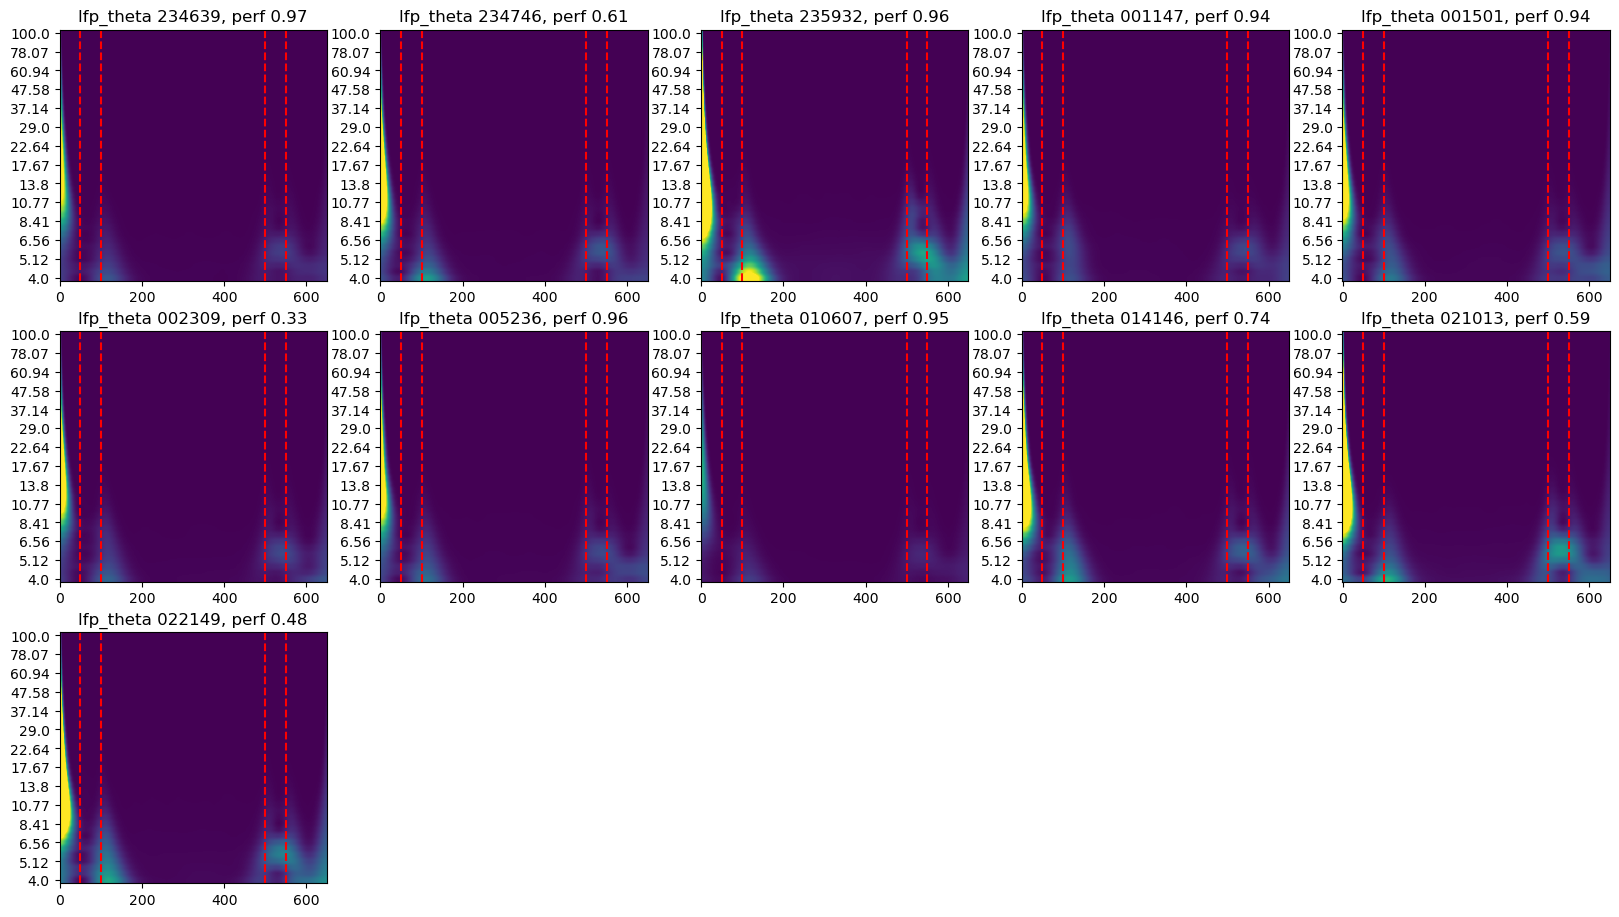

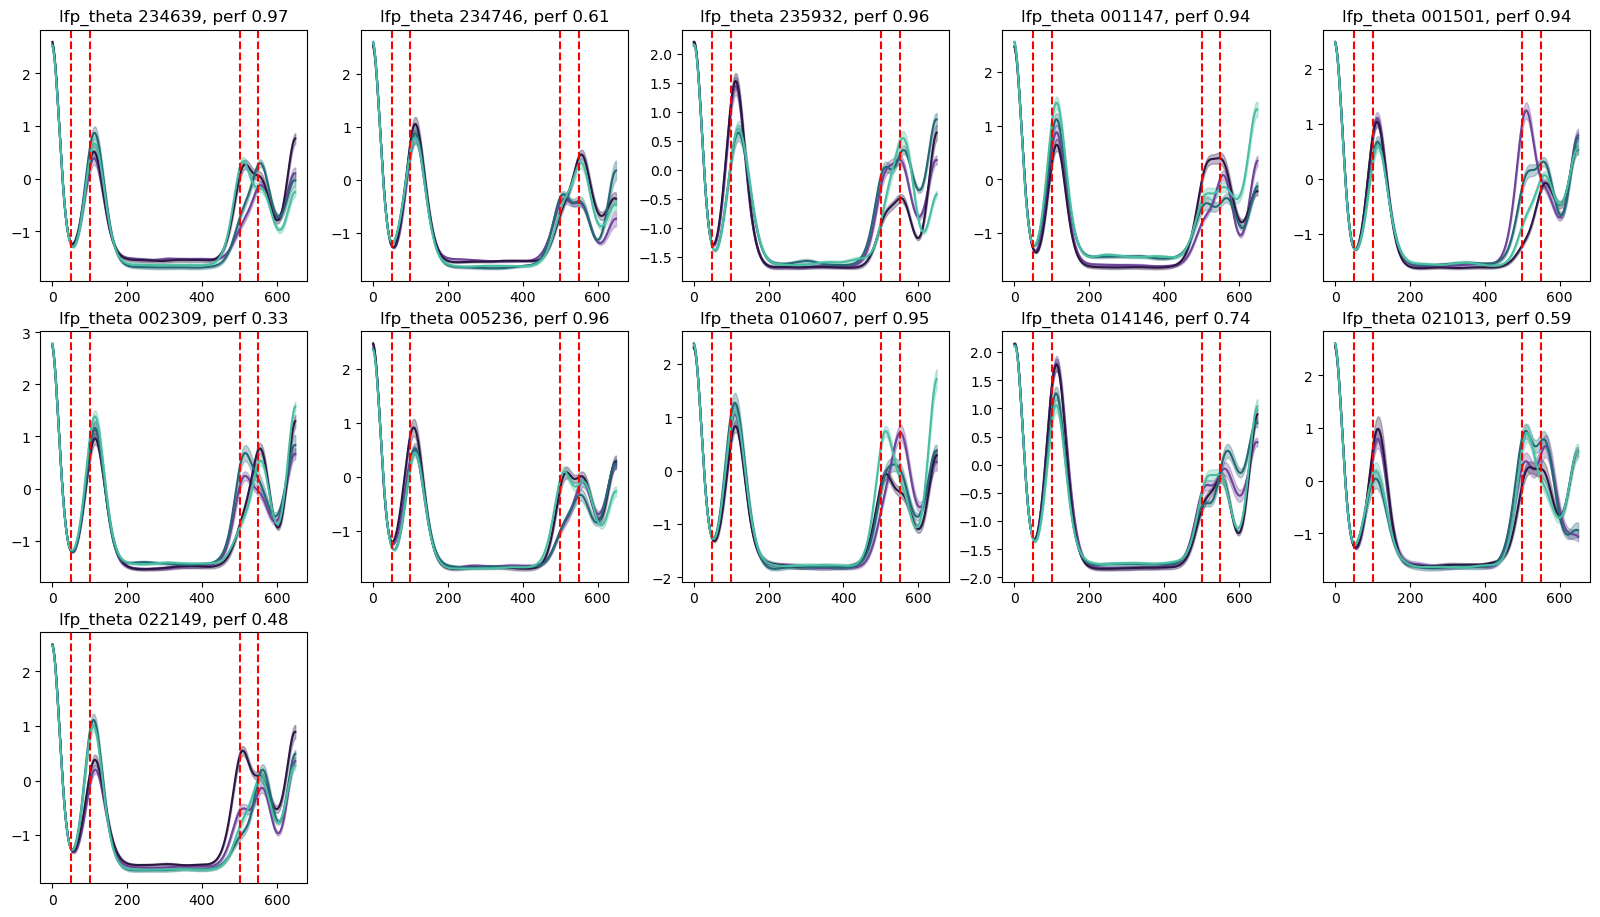

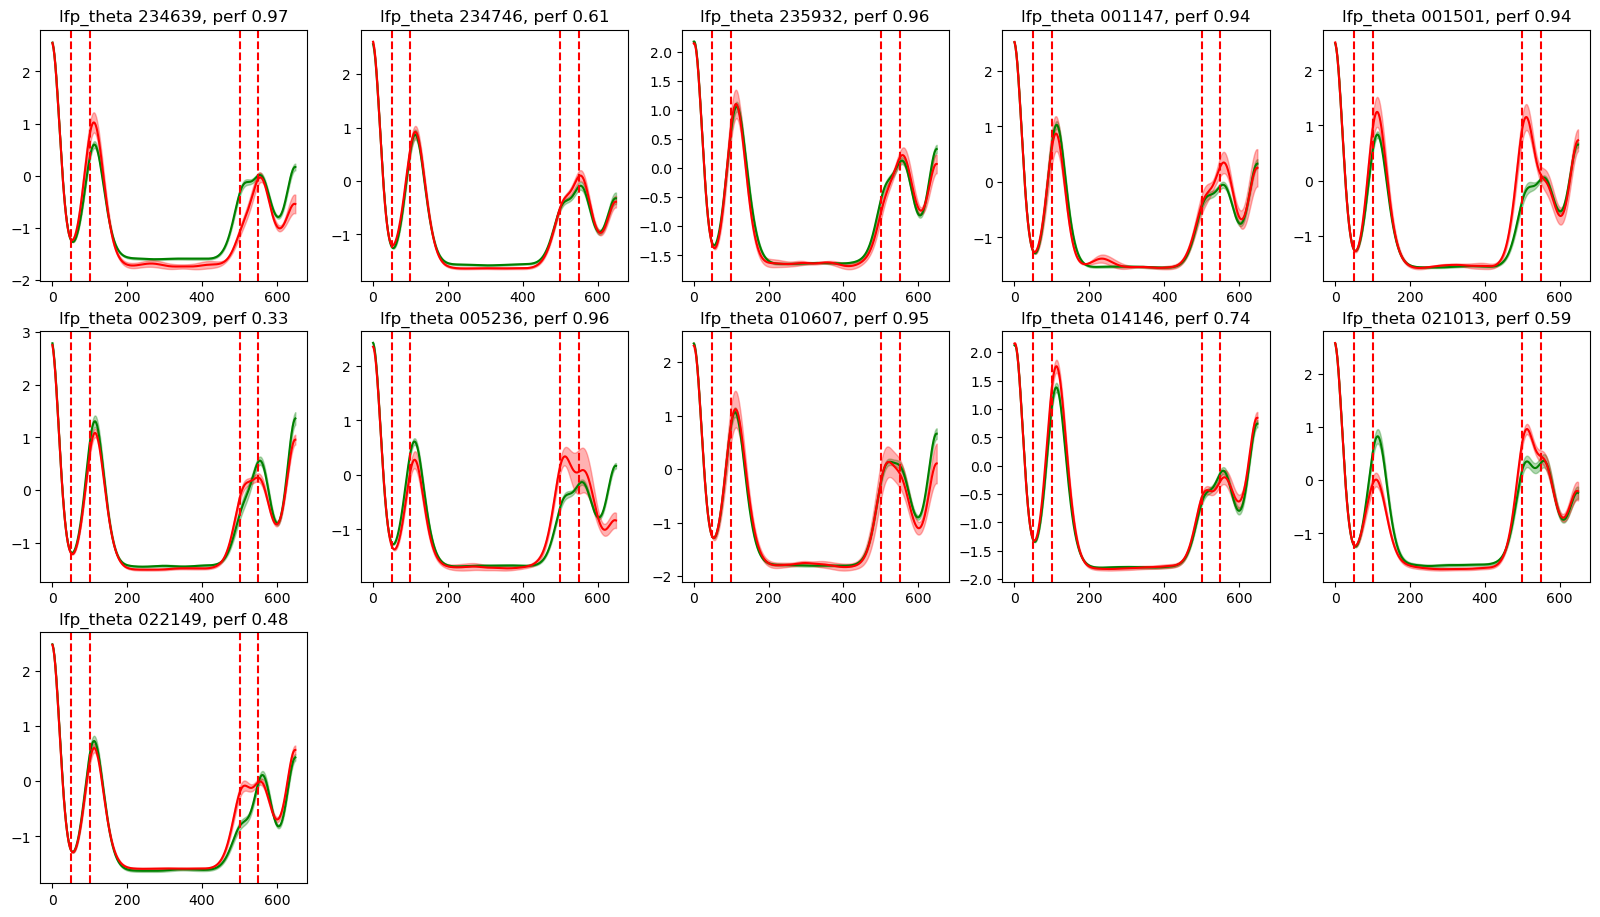

In [7]:
# make plots: spect, bandpower by trial type, bandpower by correct/incorrect

model_list = lfp_theta_model_list
model_dir = lfp_model_dir
model_list_name = 'lfp_theta'

print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')

# create figure
fig1 = plt.figure(figsize=(20, 15)) # spectrogram
fig2 = plt.figure(figsize=(20, 15)) # band power, split by trial type
fig3 = plt.figure(figsize=(20, 15)) # band power, split by correct/incorrect

for model_name in model_list:
    # print(f"\nModel: {model_name}")
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    
    # get neural and behavioral data
    neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict_delay400.pkl'), 'rb'))
    bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict_delay400.pkl'), 'rb'))
    
    # calculate spectrogram data for all trials
    n_freqs = 40
    n_trials = neural_dict['epsp'].shape[0]

    trial_powerband = np.zeros((n_trials, settings['T'])) # [N, T]
    avg_power = np.zeros((settings['T'], n_freqs)) # [T, F]
    for i in range(n_trials):
        trial_power, freqs, trial_powerband[i, :] = compute_lfp_power_np(neural_dict['epsp'][i, :], settings)
        avg_power += trial_power / n_trials
        
    # first plot spectrogram
    ax1 = fig1.add_subplot(4, 5, model_list.index(model_name)+1)
    ax1.imshow(avg_power.T, aspect='auto', origin='lower',
            vmin=0, vmax=1.2)
    ax1.set_yticks(np.arange(0, 40, 3), np.round(freqs[::3], 2))
    # ax1.colorbar(label='Power')
    ax1.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    ax1.axvline(x=settings['stim_on'], color='r', linestyle='--')
    ax1.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
    ax1.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
    ax1.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')
    
    # then plot band power, split by trial type
    ax2 = fig2.add_subplot(4, 5, model_list.index(model_name)+1)
    stims, colors = ld.get_trialtype_colors()
    trial_types, trial_idxs = np.unique(np.array(bhv_dict['trial_type']), axis=0, return_inverse=True)
    for i, trial_type in enumerate(trial_types):
        trials_idx = (trial_idxs == i)
        powerband_mean = np.mean(trial_powerband[trials_idx, :], axis=0)
        powerband_sem = np.std(trial_powerband[trials_idx, :], axis=0) / np.sqrt(np.sum(trials_idx))
        ax2.plot(powerband_mean, color=colors[i])#, label=stims[i])
        ax2.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color=colors[i], alpha=0.3)
    ax2.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    ax2.axvline(x=settings['stim_on'], color='r', linestyle='--')
    ax2.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
    ax2.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
    ax2.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')
    
    # finally plot band power, split by correct/incorrect
    ax3 = fig3.add_subplot(4, 5, model_list.index(model_name)+1)
    correct_trials = (np.array(bhv_dict['perf']) == 1)
    incorrect_trials = (np.array(bhv_dict['perf']) == 0)
    powerband_mean = np.mean(trial_powerband[correct_trials, :], axis=0)
    powerband_sem = np.std(trial_powerband[correct_trials, :], axis=0) / np.sqrt(np.sum(correct_trials))
    ax3.plot(powerband_mean, color='g', label='correct')
    ax3.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='g', alpha=0.3)
    powerband_mean = np.mean(trial_powerband[incorrect_trials, :], axis=0)
    powerband_sem = np.std(trial_powerband[incorrect_trials, :], axis=0) / np.sqrt(np.sum(incorrect_trials))
    ax3.plot(powerband_mean, color='r', label='incorrect')
    ax3.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='r', alpha=0.3)
    ax3.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    ax3.axvline(x=settings['stim_on'], color='r', linestyle='--')
    ax3.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
    ax3.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
    ax3.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')



Processing model type: lfp_theta, number of models: 2


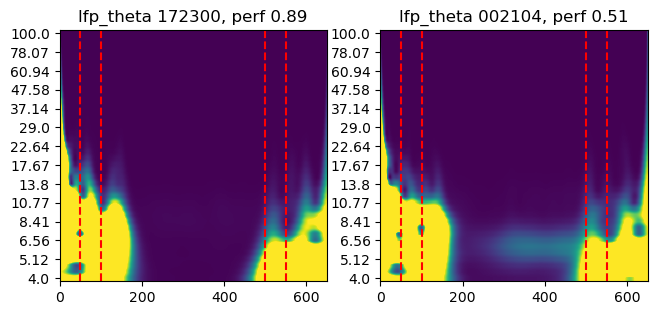

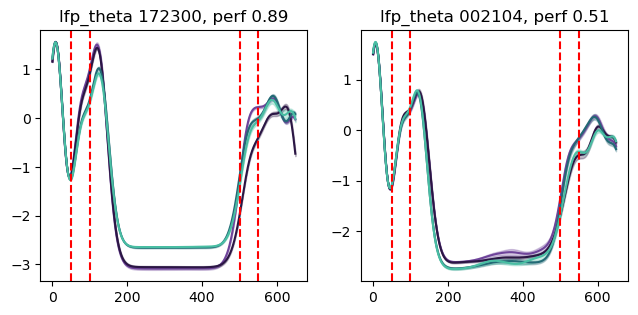

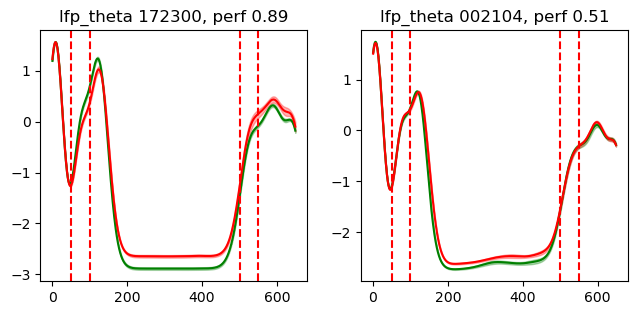

In [10]:
# make plots: spect, bandpower by trial type, bandpower by correct/incorrect

model_list = lfp_theta_model_list
model_dir = lfp_model_dir
model_list_name = 'lfp_theta'

print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')

# create figure
fig1 = plt.figure(figsize=(20, 15)) # spectrogram
fig2 = plt.figure(figsize=(20, 15)) # band power, split by trial type
fig3 = plt.figure(figsize=(20, 15)) # band power, split by correct/incorrect

for model_name in model_list:
    # print(f"\nModel: {model_name}")
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    
    # get neural and behavioral data
    neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict_delay400.pkl'), 'rb'))
    bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict_delay400.pkl'), 'rb'))
    
    # calculate spectrogram data for all trials
    n_freqs = 40
    n_trials = neural_dict['epsp'].shape[0]

    trial_powerband = np.zeros((n_trials, settings['T'])) # [N, T]
    avg_power = np.zeros((settings['T'], n_freqs)) # [T, F]
    for i in range(n_trials):
        trial_power, freqs, trial_powerband[i, :] = compute_lfp_power_np(neural_dict['epsp'][i, :], settings)
        avg_power += trial_power / n_trials
        
    # first plot spectrogram
    ax1 = fig1.add_subplot(4, 5, model_list.index(model_name)+1)
    ax1.imshow(avg_power.T, aspect='auto', origin='lower',
            vmin=0, vmax=1.2)
    ax1.set_yticks(np.arange(0, 40, 3), np.round(freqs[::3], 2))
    # ax1.colorbar(label='Power')
    ax1.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    ax1.axvline(x=settings['stim_on'], color='r', linestyle='--')
    ax1.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
    ax1.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
    ax1.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')
    
    # then plot band power, split by trial type
    ax2 = fig2.add_subplot(4, 5, model_list.index(model_name)+1)
    stims, colors = ld.get_trialtype_colors()
    trial_types, trial_idxs = np.unique(np.array(bhv_dict['trial_type']), axis=0, return_inverse=True)
    for i, trial_type in enumerate(trial_types):
        trials_idx = (trial_idxs == i)
        powerband_mean = np.mean(trial_powerband[trials_idx, :], axis=0)
        powerband_sem = np.std(trial_powerband[trials_idx, :], axis=0) / np.sqrt(np.sum(trials_idx))
        ax2.plot(powerband_mean, color=colors[i])#, label=stims[i])
        ax2.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color=colors[i], alpha=0.3)
    ax2.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    ax2.axvline(x=settings['stim_on'], color='r', linestyle='--')
    ax2.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
    ax2.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
    ax2.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')
    
    # finally plot band power, split by correct/incorrect
    ax3 = fig3.add_subplot(4, 5, model_list.index(model_name)+1)
    correct_trials = (np.array(bhv_dict['perf']) == 1)
    incorrect_trials = (np.array(bhv_dict['perf']) == 0)
    powerband_mean = np.mean(trial_powerband[correct_trials, :], axis=0)
    powerband_sem = np.std(trial_powerband[correct_trials, :], axis=0) / np.sqrt(np.sum(correct_trials))
    ax3.plot(powerband_mean, color='g', label='correct')
    ax3.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='g', alpha=0.3)
    powerband_mean = np.mean(trial_powerband[incorrect_trials, :], axis=0)
    powerband_sem = np.std(trial_powerband[incorrect_trials, :], axis=0) / np.sqrt(np.sum(incorrect_trials))
    ax3.plot(powerband_mean, color='r', label='incorrect')
    ax3.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='r', alpha=0.3)
    ax3.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    ax3.axvline(x=settings['stim_on'], color='r', linestyle='--')
    ax3.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
    ax3.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
    ax3.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')



Processing model type: lfp_theta, number of models: 11


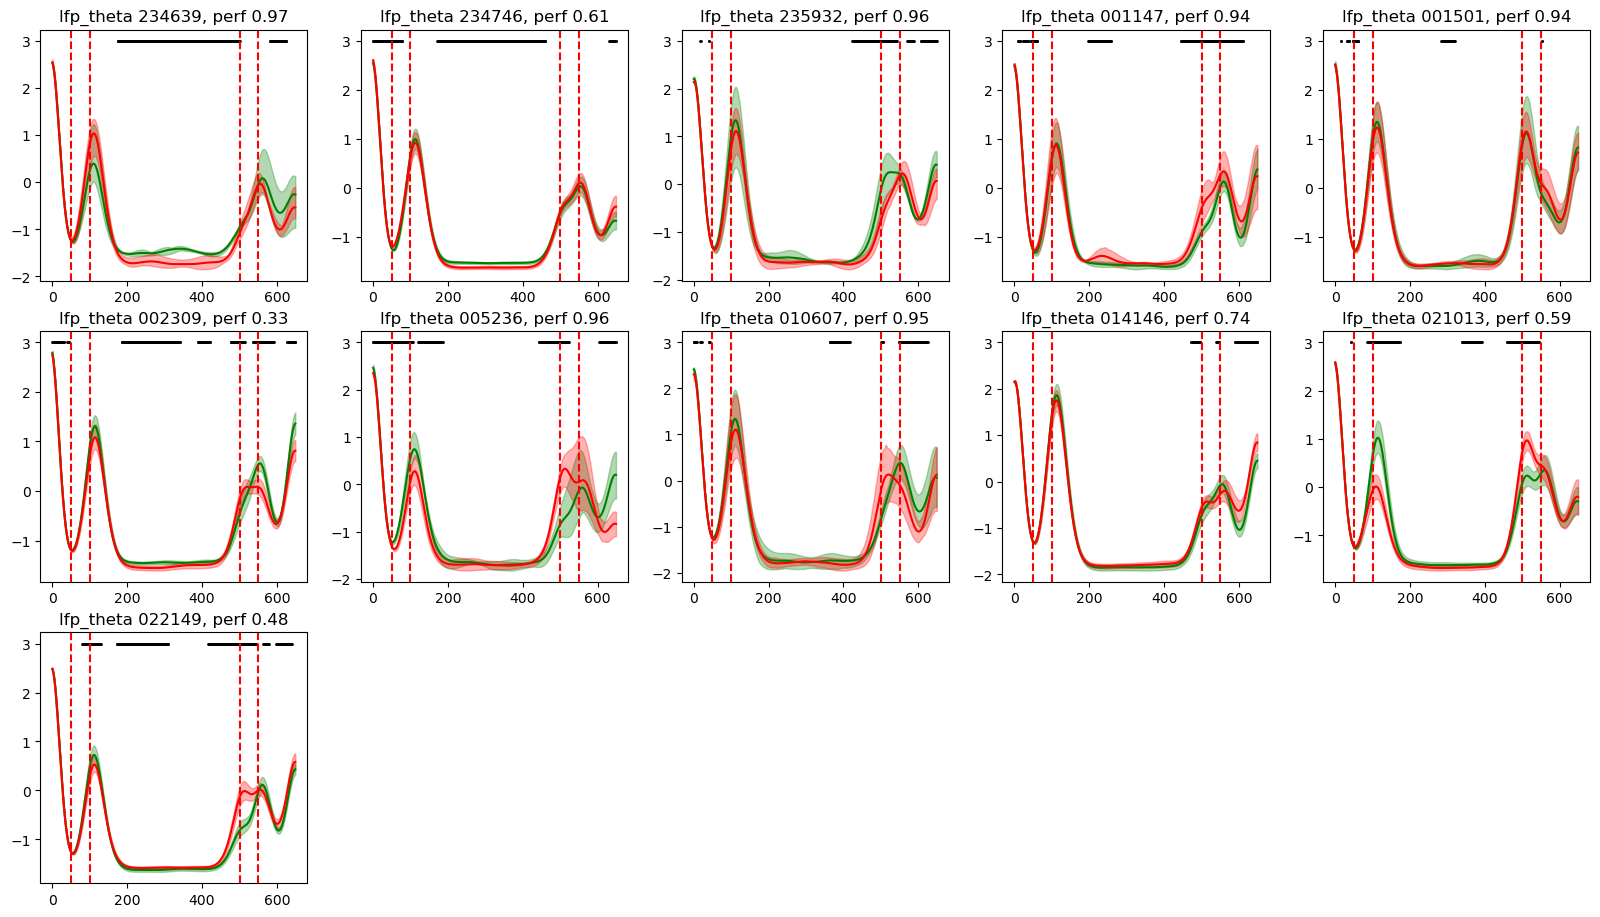

In [8]:
# make plot: bandpower by correct/incorrect w bootstrapping

from bootstrap_method import fnc_time_bootstrap_optimized_retX

random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)


print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')

# create figure
fig = plt.figure(figsize=(20, 15)) # band power, split by correct/incorrect

for model_name in model_list:
    # print(f"\nModel: {model_name}")
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    
    # get neural and behavioral data
    neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict_delay400.pkl'), 'rb'))
    bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict_delay400.pkl'), 'rb'))
    
    # calculate spectrogram data for all trials
    n_freqs = 40
    n_trials = neural_dict['epsp'].shape[0]

    trial_powerband = np.zeros((n_trials, settings['T'])) # [N, T]
    avg_power = np.zeros((settings['T'], n_freqs)) # [T, F]
    for i in range(n_trials):
        trial_power, freqs, trial_powerband[i, :] = compute_lfp_power_np(neural_dict['epsp'][i, :], settings)
        avg_power += trial_power / n_trials
        
    # finally plot band power, split by correct/incorrect
    ax = fig.add_subplot(4, 5, model_list.index(model_name)+1)
    correct_trials = (np.array(bhv_dict['perf']) == 1)
    incorrect_trials = (np.array(bhv_dict['perf']) == 0)
    
    t1_avg, t1_CI, t2_avg, t2_CI, diff_avg, diff_CI, p_diff = fnc_time_bootstrap_optimized_retX(trial_powerband[correct_trials, :], 
                                                                                            trial_powerband[incorrect_trials, :], 
                                                                                            nboot, CI_int, n_jobs=-1, random_seed=None)
    
    ax.plot(t1_avg.mean(axis=1), color='g', label='correct')
    ax.fill_between(np.arange(settings['T']), t1_CI[:,0], t1_CI[:,1], color='g', alpha=0.3)
    powerband_mean = np.mean(trial_powerband[incorrect_trials, :], axis=0)
    powerband_sem = np.std(trial_powerband[incorrect_trials, :], axis=0) / np.sqrt(np.sum(incorrect_trials))
    ax.plot(t2_avg.mean(axis=1), color='r', label='incorrect')
    ax.fill_between(np.arange(settings['T']), t2_CI[:,0], t2_CI[:,1], color='r', alpha=0.3)
    # plot bar for significant difference
    sig_idx = np.where(p_diff < 0.05)[0]
    ax.scatter(sig_idx, np.ones_like(sig_idx)*3, color='k', s=1)
    ax.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    ax.axvline(x=settings['stim_on'], color='r', linestyle='--')
    ax.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
    ax.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
    ax.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')



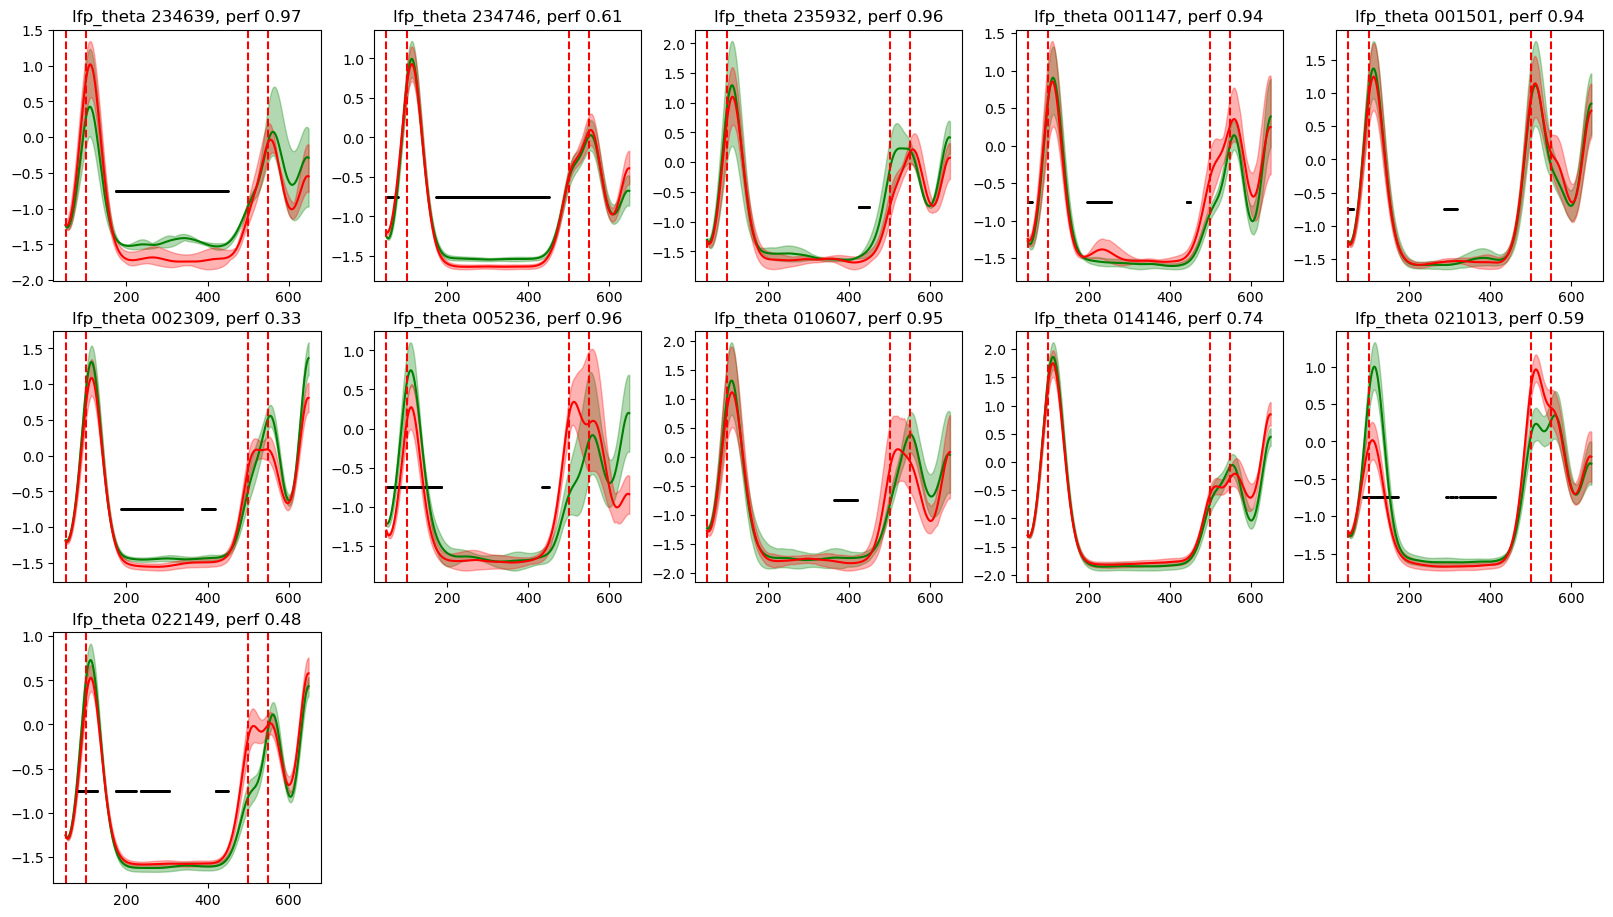

In [11]:
# make plot: bandpower by correct/incorrect w bootstrapping (cutting x-axis)

from bootstrap_method import fnc_time_bootstrap_optimized_retX

random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)


# create figure
fig = plt.figure(figsize=(20, 15)) # band power, split by correct/incorrect

for model_name in model_list:
    # print(f"\nModel: {model_name}")
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    
    # get neural and behavioral data
    neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict_delay400.pkl'), 'rb'))
    bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict_delay400.pkl'), 'rb'))
    
    # calculate spectrogram data for all trials
    n_freqs = 40
    n_trials = neural_dict['epsp'].shape[0]

    trial_powerband = np.zeros((n_trials, settings['T'])) # [N, T]
    avg_power = np.zeros((settings['T'], n_freqs)) # [T, F]
    for i in range(n_trials):
        trial_power, freqs, trial_powerband[i, :] = compute_lfp_power_np(neural_dict['epsp'][i, :], settings)
        avg_power += trial_power / n_trials
        
    # finally plot band power, split by correct/incorrect
    ax = fig.add_subplot(4, 5, model_list.index(model_name)+1)
    correct_trials = (np.array(bhv_dict['perf']) == 1)
    incorrect_trials = (np.array(bhv_dict['perf']) == 0)
    
    t1_avg, t1_CI, t2_avg, t2_CI, diff_avg, diff_CI, p_diff = fnc_time_bootstrap_optimized_retX(trial_powerband[correct_trials, :], 
                                                                                            trial_powerband[incorrect_trials, :], 
                                                                                            nboot, CI_int, n_jobs=-1, random_seed=None)
    plot_x = np.arange(50, 650)
    ax.plot(plot_x, t1_avg.mean(axis=1)[plot_x], color='g', label='correct')
    ax.fill_between(plot_x, t1_CI[plot_x,0], t1_CI[plot_x,1], color='g', alpha=0.3)
    ax.plot(plot_x, t2_avg.mean(axis=1)[plot_x], color='r', label='incorrect')
    ax.fill_between(plot_x, t2_CI[plot_x,0], t2_CI[plot_x,1], color='r', alpha=0.3)
    # plot bar for significant difference
    sig_idx = np.where(p_diff < 0.05)[0]
    sig_idx = sig_idx[(sig_idx>=50) & (sig_idx<=450)]
    ax.scatter(sig_idx, np.ones_like(sig_idx)*-0.75, color='k', s=1)
    ax.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    ax.axvline(x=settings['stim_on'], color='r', linestyle='--')
    ax.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
    ax.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
    ax.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')

plt.show()



#### jitter=30

In [3]:
# lfp models (lfp) — theta; jitter30

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
# lfp_model_list = os.listdir(lfp_model_dir)
# lfp_model_list = [m for m in lfp_model_list if m.endswith('.mat') and m.]
lfp_theta_model_list = ld.find_files_keywords(lfp_model_dir, ['Jitter_10_30', '4.0_8.0', '.mat'])
# remove directories 
lfp_theta_model_list = [m.split('/')[-1] for m in lfp_theta_model_list]
lfp_theta_model_list.sort()

# remove the last model, which was trained with different parameters
lfp_theta_model_list = lfp_theta_model_list[:-1]
# print(lfp_theta_model_list)
print(len(lfp_theta_model_list))

perfs = []
train_trials = []
for i, model_name in enumerate(lfp_theta_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

6
Model: Task_xor_N_200_Jitter_10_30_LFP_4.0_8.0_2025_09_10_164636.mat, Test perf: 1.0, Train trials: 14101
Model: Task_xor_N_200_Jitter_10_30_LFP_4.0_8.0_2025_09_10_174734.mat, Test perf: 1.0, Train trials: 13101
Model: Task_xor_N_200_Jitter_10_30_LFP_4.0_8.0_2025_09_11_120848.mat, Test perf: 1.0, Train trials: 10401
Model: Task_xor_N_200_Jitter_10_30_LFP_4.0_8.0_2025_09_11_121524.mat, Test perf: 1.0, Train trials: 3701
Model: Task_xor_N_200_Jitter_10_30_LFP_4.0_8.0_2025_09_11_124457.mat, Test perf: 1.0, Train trials: 33001
Model: Task_xor_N_200_Jitter_10_30_LFP_4.0_8.0_2025_09_11_124518.mat, Test perf: 1.0, Train trials: 18301


In [4]:
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4, 8], # theta
        'fs': 200,
        'task': 'xor', # task name
        }

Mann-Whitney U test statistic: 36.00, p-value: 0.00


/tmp/ipykernel_399454/752809789.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([perfs, perfs_delay400], labels=['delay 50', 'delay 400'])


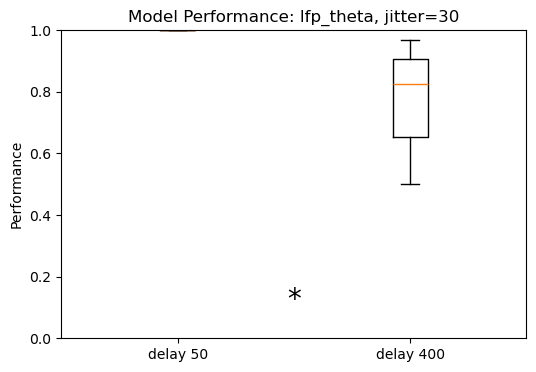

In [5]:
# performance plots, jitter=30

model_list = lfp_theta_model_list
model_dir = lfp_model_dir
model_list_name = 'lfp_theta'

# create figure
fig = plt.figure(figsize=(6, 4))

perfs_delay400 = []
for model_name in model_list:
    # print(f"\nModel: {model_name}")
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    
    # get neural and behavioral data
    # neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict_delay400.pkl'), 'rb'))
    bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict_delay400.pkl'), 'rb'))
    perfs_delay400.append(np.mean(bhv_dict['perf']))
    
# plot perfs and perfs_delay400
plt.boxplot([perfs, perfs_delay400], labels=['delay 50', 'delay 400'])
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(perfs, perfs_delay400)
print("Mann-Whitney U test statistic: %.2f, p-value: %.2f" % (stat, p))
if p<0.05:
    plt.text(1.5, 0.1, '*', fontsize=20, ha='center')
plt.ylabel('Performance')
plt.title(f'Model Performance: {model_list_name}, jitter=30')
plt.ylim([0, 1])
plt.show()

Processing model type: lfp_theta, number of models: 6


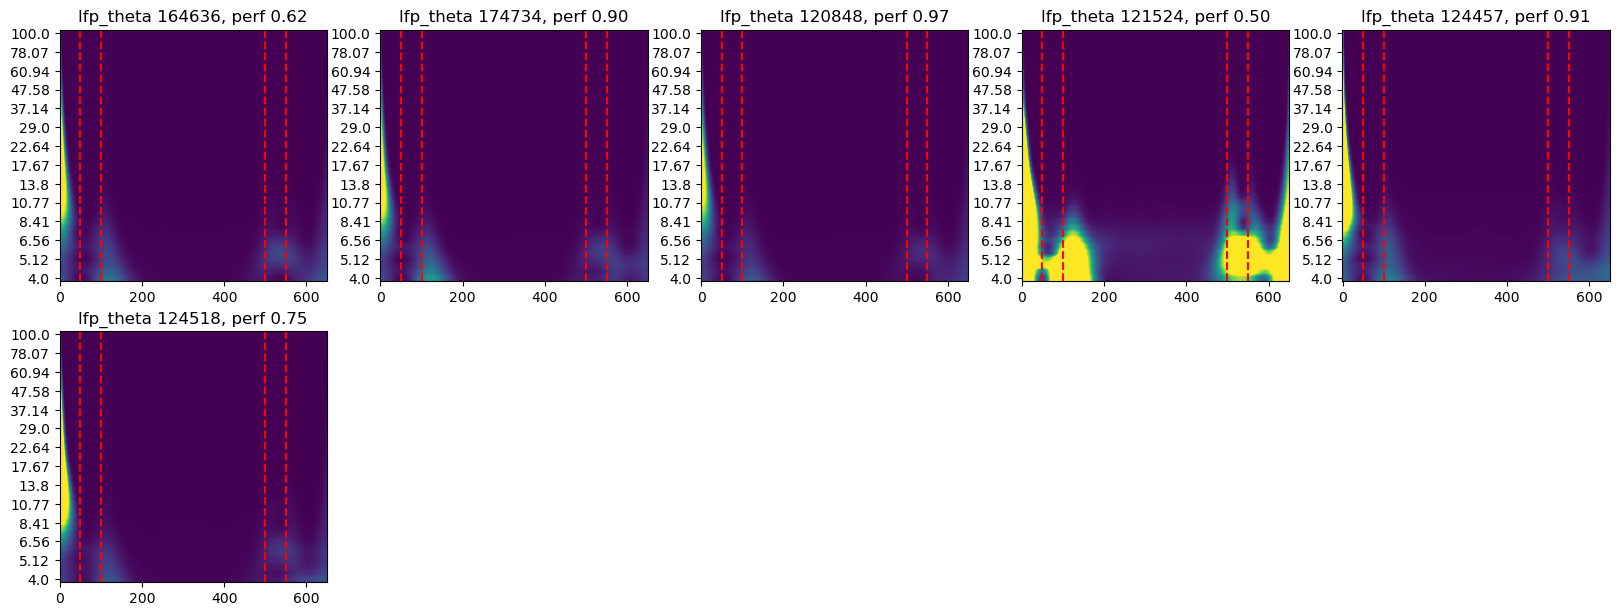

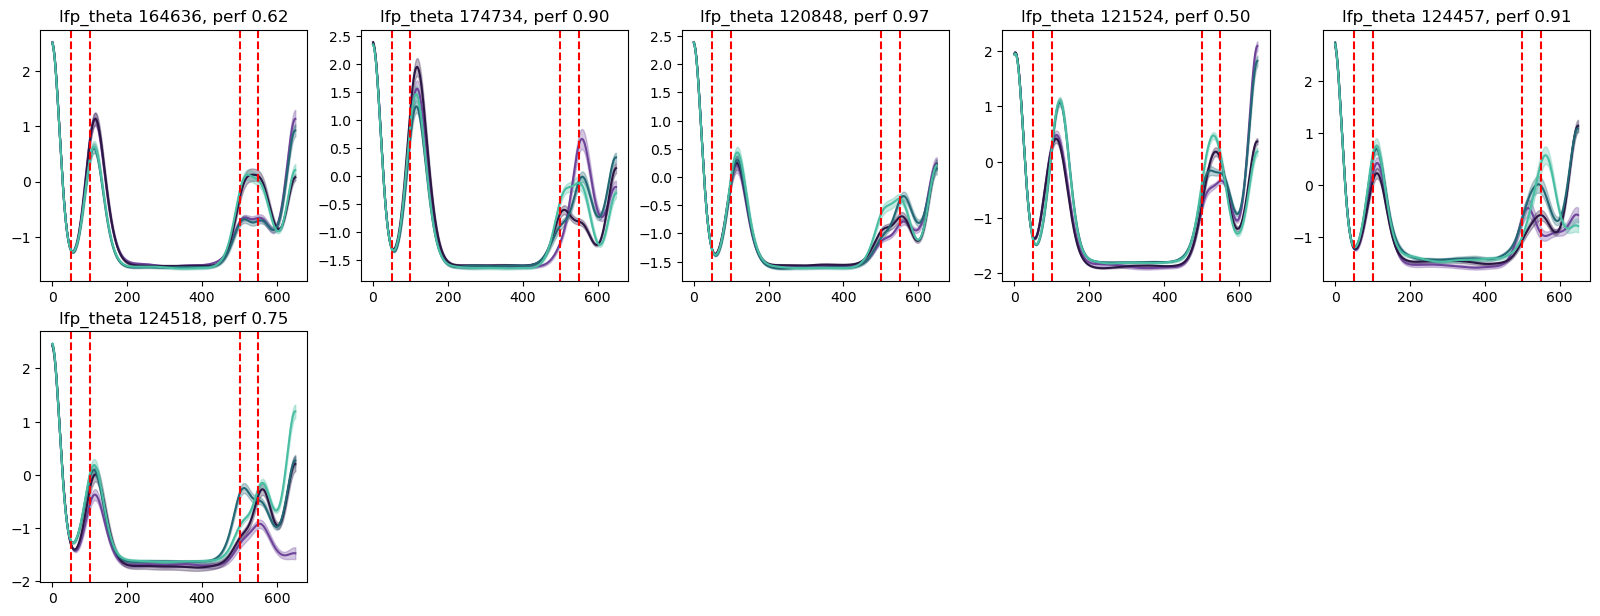

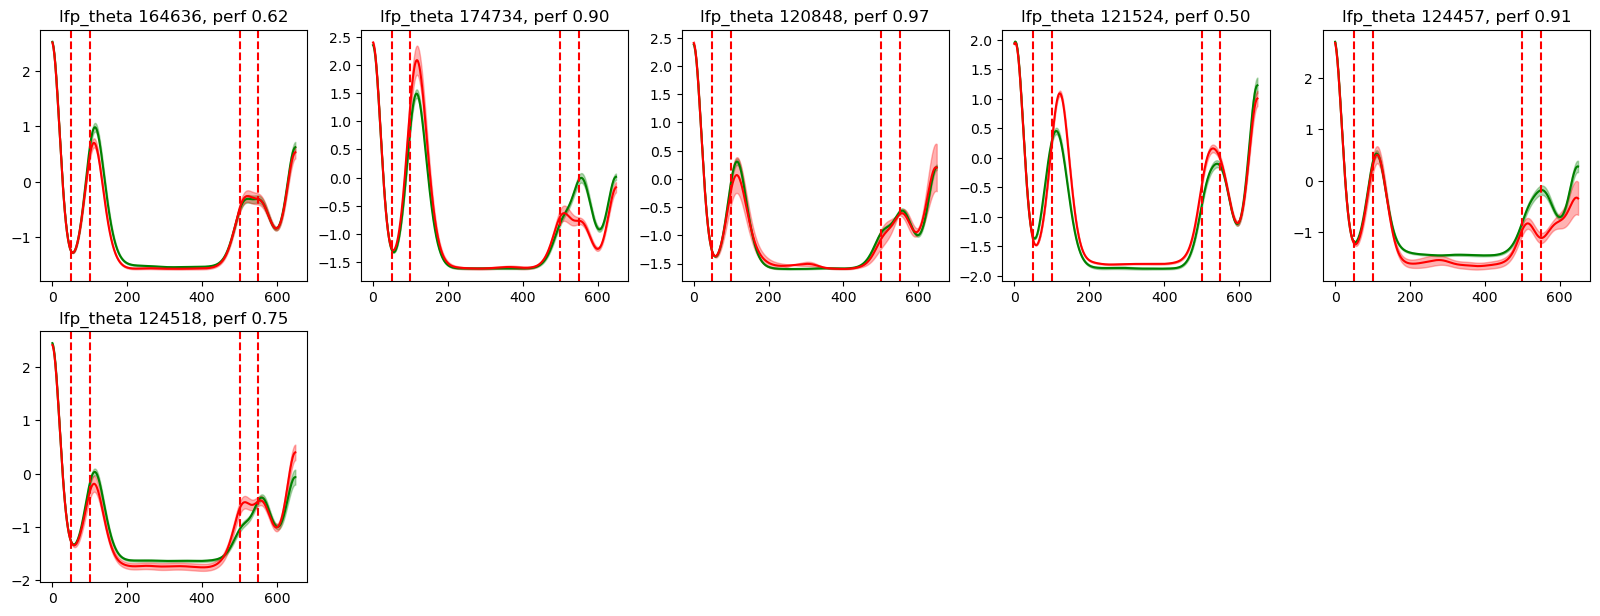

In [8]:
# make plots: spect, bandpower by trial type, bandpower by correct/incorrect

model_list = lfp_theta_model_list
model_dir = lfp_model_dir
model_list_name = 'lfp_theta'

print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')

# create figure
fig1 = plt.figure(figsize=(20, 15)) # spectrogram
fig2 = plt.figure(figsize=(20, 15)) # band power, split by trial type
fig3 = plt.figure(figsize=(20, 15)) # band power, split by correct/incorrect

for model_name in model_list:
    # print(f"\nModel: {model_name}")
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    
    # get neural and behavioral data
    neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict_delay400.pkl'), 'rb'))
    bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict_delay400.pkl'), 'rb'))
    
    # calculate spectrogram data for all trials
    n_freqs = 40
    n_trials = neural_dict['epsp'].shape[0]

    trial_powerband = np.zeros((n_trials, settings['T'])) # [N, T]
    avg_power = np.zeros((settings['T'], n_freqs)) # [T, F]
    for i in range(n_trials):
        trial_power, freqs, trial_powerband[i, :] = compute_lfp_power_np(neural_dict['epsp'][i, :], settings)
        avg_power += trial_power / n_trials
        
    # first plot spectrogram
    ax1 = fig1.add_subplot(4, 5, model_list.index(model_name)+1)
    ax1.imshow(avg_power.T, aspect='auto', origin='lower',
            vmin=0, vmax=1.2)
    ax1.set_yticks(np.arange(0, 40, 3), np.round(freqs[::3], 2))
    # ax1.colorbar(label='Power')
    ax1.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    ax1.axvline(x=settings['stim_on'], color='r', linestyle='--')
    ax1.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
    ax1.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
    ax1.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')
    
    # then plot band power, split by trial type
    ax2 = fig2.add_subplot(4, 5, model_list.index(model_name)+1)
    stims, colors = ld.get_trialtype_colors()
    trial_types, trial_idxs = np.unique(np.array(bhv_dict['trial_type']), axis=0, return_inverse=True)
    for i, trial_type in enumerate(trial_types):
        trials_idx = (trial_idxs == i)
        powerband_mean = np.mean(trial_powerband[trials_idx, :], axis=0)
        powerband_sem = np.std(trial_powerband[trials_idx, :], axis=0) / np.sqrt(np.sum(trials_idx))
        ax2.plot(powerband_mean, color=colors[i])#, label=stims[i])
        ax2.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color=colors[i], alpha=0.3)
    ax2.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    ax2.axvline(x=settings['stim_on'], color='r', linestyle='--')
    ax2.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
    ax2.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
    ax2.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')
    
    # finally plot band power, split by correct/incorrect
    ax3 = fig3.add_subplot(4, 5, model_list.index(model_name)+1)
    correct_trials = (np.array(bhv_dict['perf']) == 1)
    incorrect_trials = (np.array(bhv_dict['perf']) == 0)
    powerband_mean = np.mean(trial_powerband[correct_trials, :], axis=0)
    powerband_sem = np.std(trial_powerband[correct_trials, :], axis=0) / np.sqrt(np.sum(correct_trials))
    ax3.plot(powerband_mean, color='g', label='correct')
    ax3.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='g', alpha=0.3)
    powerband_mean = np.mean(trial_powerband[incorrect_trials, :], axis=0)
    powerband_sem = np.std(trial_powerband[incorrect_trials, :], axis=0) / np.sqrt(np.sum(incorrect_trials))
    ax3.plot(powerband_mean, color='r', label='incorrect')
    ax3.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='r', alpha=0.3)
    ax3.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    ax3.axvline(x=settings['stim_on'], color='r', linestyle='--')
    ax3.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
    ax3.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
    ax3.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')



Processing model type: lfp_theta, number of models: 6


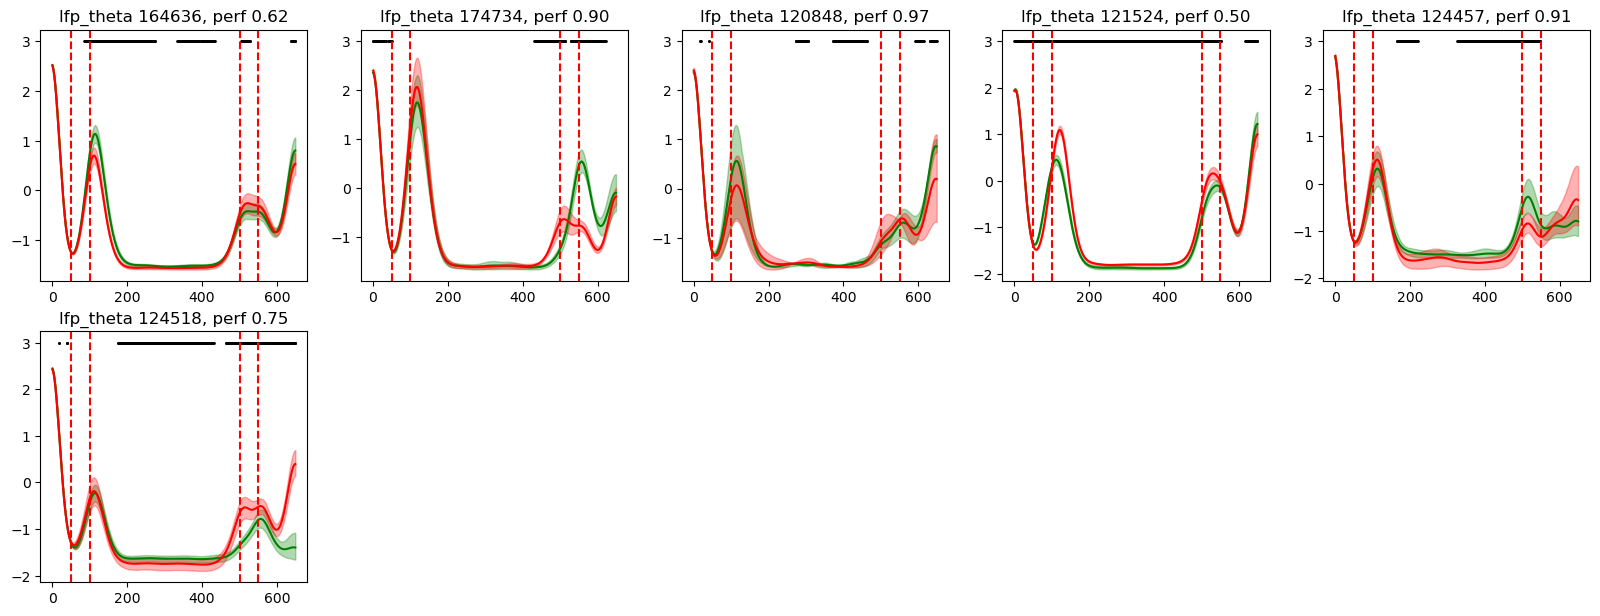

In [9]:
# make plot: bandpower by correct/incorrect w bootstrapping

from bootstrap_method import fnc_time_bootstrap_optimized_retX

random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)


print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')

# create figure
fig = plt.figure(figsize=(20, 15)) # band power, split by correct/incorrect

for model_name in model_list:
    # print(f"\nModel: {model_name}")
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    
    # get neural and behavioral data
    neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict_delay400.pkl'), 'rb'))
    bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict_delay400.pkl'), 'rb'))
    
    # calculate spectrogram data for all trials
    n_freqs = 40
    n_trials = neural_dict['epsp'].shape[0]

    trial_powerband = np.zeros((n_trials, settings['T'])) # [N, T]
    avg_power = np.zeros((settings['T'], n_freqs)) # [T, F]
    for i in range(n_trials):
        trial_power, freqs, trial_powerband[i, :] = compute_lfp_power_np(neural_dict['epsp'][i, :], settings)
        avg_power += trial_power / n_trials
        
    # finally plot band power, split by correct/incorrect
    ax = fig.add_subplot(4, 5, model_list.index(model_name)+1)
    correct_trials = (np.array(bhv_dict['perf']) == 1)
    incorrect_trials = (np.array(bhv_dict['perf']) == 0)
    
    t1_avg, t1_CI, t2_avg, t2_CI, diff_avg, diff_CI, p_diff = fnc_time_bootstrap_optimized_retX(trial_powerband[correct_trials, :], 
                                                                                            trial_powerband[incorrect_trials, :], 
                                                                                            nboot, CI_int, n_jobs=-1, random_seed=None)
    
    ax.plot(t1_avg.mean(axis=1), color='g', label='correct')
    ax.fill_between(np.arange(settings['T']), t1_CI[:,0], t1_CI[:,1], color='g', alpha=0.3)
    powerband_mean = np.mean(trial_powerband[incorrect_trials, :], axis=0)
    powerband_sem = np.std(trial_powerband[incorrect_trials, :], axis=0) / np.sqrt(np.sum(incorrect_trials))
    ax.plot(t2_avg.mean(axis=1), color='r', label='incorrect')
    ax.fill_between(np.arange(settings['T']), t2_CI[:,0], t2_CI[:,1], color='r', alpha=0.3)
    # plot bar for significant difference
    sig_idx = np.where(p_diff < 0.05)[0]
    ax.scatter(sig_idx, np.ones_like(sig_idx)*3, color='k', s=1)
    ax.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    ax.axvline(x=settings['stim_on'], color='r', linestyle='--')
    ax.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
    ax.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
    ax.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')

